In [ ]:
!pip -q install fair-esm biopython scikit-learn matplotlib pandas requests

In [ ]:
import io
import math
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

import torch
import esm

In [ ]:
def fetch_uniprot_fasta(uniprot_id: str):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    record = next(SeqIO.parse(io.StringIO(r.text), "fasta"))
    return str(record.seq), record.description

tp53_seq, tp53_desc = fetch_uniprot_fasta("P04637")

print(tp53_desc)
print("Length:", len(tp53_seq))
print(tp53_seq[:80] + "...")

sp|P04637|P53_HUMAN Cellular tumor antigen p53 OS=Homo sapiens OX=9606 GN=TP53 PE=1 SV=4
Length: 393
MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAP...


In [ ]:
position_groups = {
    "hotspot":         [175, 220, 245, 248],
    "structural":      [176, 179, 249, 282],
    "comparison_dbd":  [125, 138, 151, 157],
}

all_positions = []
for group, pos_list in position_groups.items():
    for p in pos_list:
        all_positions.append((p, group))

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

print(all_positions)

[(175, 'hotspot'), (220, 'hotspot'), (245, 'hotspot'), (248, 'hotspot'), (176, 'structural'), (179, 'structural'), (249, 'structural'), (282, 'structural'), (125, 'comparison_dbd'), (138, 'comparison_dbd'), (151, 'comparison_dbd'), (157, 'comparison_dbd')]


In [ ]:
for pos, group in all_positions:
    wt_aa = tp53_seq[pos - 1]
    print(f"{group:15s} {wt_aa}{pos}")

hotspot         R175
hotspot         Y220
hotspot         G245
hotspot         R248
structural      C176
structural      H179
structural      R249
structural      R282
comparison_dbd  T125
comparison_dbd  A138
comparison_dbd  P151
comparison_dbd  V157


In [ ]:
def generate_single_mutants_with_metadata(seq, positions_with_groups, amino_acids):
    mutants = []
    seq_list = list(seq)

    for pos_1based, group in positions_with_groups:
        idx = pos_1based - 1
        wt_aa = seq_list[idx]

        for aa in amino_acids:
            if aa == wt_aa:
                continue

            mut_seq = seq_list.copy()
            mut_seq[idx] = aa
            mut_seq = "".join(mut_seq)

            mutants.append({
                "mutant": f"{wt_aa}{pos_1based}{aa}",
                "position": pos_1based,
                "wt_aa": wt_aa,
                "mut_aa": aa,
                "group": group,
                "sequence": mut_seq,
            })

    return mutants

mutants = generate_single_mutants_with_metadata(tp53_seq, all_positions, amino_acids)

print("Number of mutants:", len(mutants))
pd.DataFrame(mutants).head()

Number of mutants: 228


,mutant,position,wt_aa,mut_aa,group,sequence
0,R175A,175,R,A,hotspot,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
1,R175C,175,R,C,hotspot,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
2,R175D,175,R,D,hotspot,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
3,R175E,175,R,E,hotspot,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
4,R175F,175,R,F,hotspot,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
#model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()
#model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
#model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()



batch_converter = alphabet.get_batch_converter()

model.eval()
model = model.to(device)

Device: cuda


In [ ]:
def get_residue_representations_batched(
    seqs_with_names,
    model,
    batch_converter,
    device="cpu",
    repr_layer=33,
    batch_size=16
):
    all_labels = []
    all_residue_reps = []

    for start in range(0, len(seqs_with_names), batch_size):
        batch = seqs_with_names[start:start + batch_size]
        batch_labels, batch_strs, batch_tokens = batch_converter(batch)
        batch_tokens = batch_tokens.to(device)

        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[repr_layer], return_contacts=False)

        token_representations = results["representations"][repr_layer]

        for i, seq in enumerate(batch_strs):
            reps = token_representations[i, 1:len(seq)+1].cpu().numpy()  # (L, d)
            all_labels.append(batch_labels[i])
            all_residue_reps.append(reps)

    return all_labels, all_residue_reps


def global_embedding_from_residue_matrix(residue_matrix):
    return residue_matrix.mean(axis=0)


def local_window_embedding(residue_matrix, pos_1based, k=5):
    idx = pos_1based - 1
    left = max(0, idx - k)
    right = min(residue_matrix.shape[0], idx + k + 1)
    return residue_matrix[left:right].mean(axis=0)


def residue_only_embedding(residue_matrix, pos_1based):
    idx = pos_1based - 1
    return residue_matrix[idx]

In [ ]:
all_sequences = [("WT", tp53_seq)] + [(m["mutant"], m["sequence"]) for m in mutants]

labels, residue_reps = get_residue_representations_batched(
    all_sequences,
    model=model,
    batch_converter=batch_converter,
    device=device,
    repr_layer=6,
    batch_size=16,
)

print("Number of sequences:", len(labels))
print("Residue matrix shape for WT:", residue_reps[0].shape)

Number of sequences: 229
Residue matrix shape for WT: (393, 320)


In [ ]:
wt_emb = global_embedding_from_residue_matrix(residue_reps[0])
print("Global embedding matrix shape:", wt_emb.shape)

Global embedding matrix shape: (320,)


In [ ]:
global_emb = np.vstack([global_embedding_from_residue_matrix(x) for x in residue_reps])
print("Global embedding matrix shape:", global_emb.shape)

Global embedding matrix shape: (229, 320)


In [ ]:
k5_emb = np.vstack([wt_emb]+[local_window_embedding(x, m["position"], k=5) for x, m in zip(residue_reps, mutants)])
print("Local k=5 embedding matrix shape:", k5_emb.shape)

Local k=5 embedding matrix shape: (229, 320)


In [ ]:
wt_residue_reps = residue_reps[0]
wt_global_emb = global_embedding_from_residue_matrix(wt_residue_reps).reshape(1, -1)

results = []

for i, m in enumerate(mutants, start=1):
    mut_residue_reps = residue_reps[i]
    pos = m["position"]

    # Global
    mut_global_emb = global_embedding_from_residue_matrix(mut_residue_reps).reshape(1, -1)
    global_cos_sim = cosine_similarity(mut_global_emb, wt_global_emb)[0, 0]
    global_cos_dist = 1.0 - global_cos_sim
    global_euc_dist = euclidean_distances(mut_global_emb, wt_global_emb)[0, 0]

    # Local k=0
    wt_k0 = residue_only_embedding(wt_residue_reps, pos).reshape(1, -1)
    mut_k0 = residue_only_embedding(mut_residue_reps, pos).reshape(1, -1)
    k0_cos_sim = cosine_similarity(mut_k0, wt_k0)[0, 0]
    k0_cos_dist = 1.0 - k0_cos_sim
    k0_euc_dist = euclidean_distances(mut_k0, wt_k0)[0, 0]

    # Local k=3
    wt_k3 = local_window_embedding(wt_residue_reps, pos, k=3).reshape(1, -1)
    mut_k3 = local_window_embedding(mut_residue_reps, pos, k=3).reshape(1, -1)
    k3_cos_sim = cosine_similarity(mut_k3, wt_k3)[0, 0]
    k3_cos_dist = 1.0 - k3_cos_sim
    k3_euc_dist = euclidean_distances(mut_k3, wt_k3)[0, 0]

    # Local k=5
    wt_k5 = local_window_embedding(wt_residue_reps, pos, k=5).reshape(1, -1)
    mut_k5 = local_window_embedding(mut_residue_reps, pos, k=5).reshape(1, -1)
    k5_cos_sim = cosine_similarity(mut_k5, wt_k5)[0, 0]
    k5_cos_dist = 1.0 - k5_cos_sim
    k5_euc_dist = euclidean_distances(mut_k5, wt_k5)[0, 0]

    results.append({
        "mutant": m["mutant"],
        "position": m["position"],
        "wt_aa": m["wt_aa"],
        "mut_aa": m["mut_aa"],
        "group": m["group"],

        "global_cosine_similarity_to_WT": float(global_cos_sim),
        "global_cosine_distance_to_WT": float(global_cos_dist),
        "global_euclidean_distance_to_WT": float(global_euc_dist),

        "k0_cosine_similarity_to_WT": float(k0_cos_sim),
        "k0_cosine_distance_to_WT": float(k0_cos_dist),
        "k0_euclidean_distance_to_WT": float(k0_euc_dist),

        "k3_cosine_similarity_to_WT": float(k3_cos_sim),
        "k3_cosine_distance_to_WT": float(k3_cos_dist),
        "k3_euclidean_distance_to_WT": float(k3_euc_dist),

        "k5_cosine_similarity_to_WT": float(k5_cos_sim),
        "k5_cosine_distance_to_WT": float(k5_cos_dist),
        "k5_euclidean_distance_to_WT": float(k5_euc_dist),
    })

df = pd.DataFrame(results)
df.head()

,mutant,position,wt_aa,mut_aa,group,global_cosine_similarity_to_WT,global_cosine_distance_to_WT,global_euclidean_distance_to_WT,k0_cosine_similarity_to_WT,k0_cosine_distance_to_WT,k0_euclidean_distance_to_WT,k3_cosine_similarity_to_WT,k3_cosine_distance_to_WT,k3_euclidean_distance_to_WT,k5_cosine_similarity_to_WT,k5_cosine_distance_to_WT,k5_euclidean_distance_to_WT
0,R175A,175,R,A,hotspot,0.999962,0.000038,0.048010,0.815292,0.184708,4.004416,0.993786,0.006214,0.665128,0.997069,0.002931,0.453276
1,R175C,175,R,C,hotspot,0.999900,0.000100,0.077952,0.850809,0.149191,3.544800,0.991256,0.008744,0.792518,0.994896,0.005104,0.599657
2,R175D,175,R,D,hotspot,0.999918,0.000082,0.071097,0.794374,0.205626,4.257302,0.990317,0.009683,0.829484,0.994595,0.005405,0.615062
3,R175E,175,R,E,hotspot,0.999925,0.000075,0.067498,0.826306,0.173694,3.854097,0.992118,0.007882,0.749500,0.995499,0.004501,0.563260
4,R175F,175,R,F,hotspot,0.999895,0.000105,0.079686,0.831564,0.168436,3.803115,0.989206,0.010794,0.875329,0.993597,0.006403,0.669166


In [ ]:
metric_cols = [
    "global_cosine_distance_to_WT",
    "k0_cosine_distance_to_WT",
    "k3_cosine_distance_to_WT",
    "k5_cosine_distance_to_WT",
]

df[metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
global_cosine_distance_to_WT,228.0,0.000071,0.000051,0.000017,0.000041,0.000053,0.000086,0.000523
k0_cosine_distance_to_WT,228.0,0.143626,0.027200,0.084735,0.124393,0.142958,0.160317,0.228609
k3_cosine_distance_to_WT,228.0,0.008957,0.005393,0.003258,0.005926,0.007417,0.009907,0.041443
k5_cosine_distance_to_WT,228.0,0.005329,0.004000,0.001603,0.003120,0.004179,0.005790,0.028881


In [ ]:
for col in metric_cols:
    print("=" * 80)
    print(col)
    display(
        df.sort_values(col, ascending=False)[
            ["mutant", "position", "group", col]
        ].head(10)
    )

global_cosine_distance_to_WT


,mutant,position,group,global_cosine_distance_to_WT
171,A138C,138,comparison_dbd,0.000523
212,V157E,157,comparison_dbd,0.000236
211,V157D,157,comparison_dbd,0.000206
39,G245C,245,hotspot,0.000199
217,V157K,157,comparison_dbd,0.000196
96,H179C,179,structural,0.000196
220,V157N,157,comparison_dbd,0.000190
93,C176W,176,structural,0.000188
209,V157A,157,comparison_dbd,0.000180
78,C176E,176,structural,0.000176


k0_cosine_distance_to_WT


,mutant,position,group,k0_cosine_distance_to_WT
211,V157D,157,comparison_dbd,0.228609
209,V157A,157,comparison_dbd,0.225121
175,A138G,138,comparison_dbd,0.220314
212,V157E,157,comparison_dbd,0.219216
2,R175D,175,hotspot,0.205626
162,T125M,125,comparison_dbd,0.201768
224,V157S,157,comparison_dbd,0.199963
154,T125D,125,comparison_dbd,0.197208
167,T125S,125,comparison_dbd,0.196853
37,Y220W,220,hotspot,0.193070


k3_cosine_distance_to_WT


,mutant,position,group,k3_cosine_distance_to_WT
212,V157E,157,comparison_dbd,0.041443
211,V157D,157,comparison_dbd,0.034809
209,V157A,157,comparison_dbd,0.030387
171,A138C,138,comparison_dbd,0.029459
222,V157Q,157,comparison_dbd,0.028227
217,V157K,157,comparison_dbd,0.026817
224,V157S,157,comparison_dbd,0.026082
214,V157G,157,comparison_dbd,0.025293
220,V157N,157,comparison_dbd,0.025252
175,A138G,138,comparison_dbd,0.024213


k5_cosine_distance_to_WT


,mutant,position,group,k5_cosine_distance_to_WT
212,V157E,157,comparison_dbd,0.028881
211,V157D,157,comparison_dbd,0.024297
209,V157A,157,comparison_dbd,0.021405
171,A138C,138,comparison_dbd,0.020641
222,V157Q,157,comparison_dbd,0.020410
217,V157K,157,comparison_dbd,0.020325
220,V157N,157,comparison_dbd,0.018527
224,V157S,157,comparison_dbd,0.018460
214,V157G,157,comparison_dbd,0.017664
223,V157R,157,comparison_dbd,0.016686


In [ ]:
summary_by_position = (
    df.groupby(["group", "position", "wt_aa"], as_index=False)
      .agg(
          n_mutants=("mutant", "count"),

          global_mean=("global_cosine_distance_to_WT", "mean"),
          global_median=("global_cosine_distance_to_WT", "median"),
          global_std=("global_cosine_distance_to_WT", "std"),
          global_max=("global_cosine_distance_to_WT", "max"),

          k0_mean=("k0_cosine_distance_to_WT", "mean"),
          k0_median=("k0_cosine_distance_to_WT", "median"),
          k0_std=("k0_cosine_distance_to_WT", "std"),
          k0_max=("k0_cosine_distance_to_WT", "max"),

          k3_mean=("k3_cosine_distance_to_WT", "mean"),
          k3_median=("k3_cosine_distance_to_WT", "median"),
          k3_std=("k3_cosine_distance_to_WT", "std"),
          k3_max=("k3_cosine_distance_to_WT", "max"),

          k5_mean=("k5_cosine_distance_to_WT", "mean"),
          k5_median=("k5_cosine_distance_to_WT", "median"),
          k5_std=("k5_cosine_distance_to_WT", "std"),
          k5_max=("k5_cosine_distance_to_WT", "max"),
      )
)

summary_by_position["site"] = summary_by_position["wt_aa"] + summary_by_position["position"].astype(str)
summary_by_position.sort_values("k5_mean", ascending=False)

,group,position,wt_aa,n_mutants,global_mean,global_median,global_std,global_max,k0_mean,k0_median,...,k0_max,k3_mean,k3_median,k3_std,k3_max,k5_mean,k5_median,k5_std,k5_max,site
3,comparison_dbd,157,V,19,0.000122,0.000131,0.000067,0.000236,0.179049,0.169530,...,0.228609,0.019369,0.022593,0.011055,0.041443,0.013381,0.015084,0.008288,0.028881,V157
8,structural,176,C,19,0.000131,0.000130,0.000024,0.000188,0.142154,0.139888,...,0.171365,0.011869,0.011909,0.001035,0.013811,0.008157,0.008030,0.000875,0.009923,C176
2,comparison_dbd,151,P,19,0.000049,0.000052,0.000015,0.000087,0.145735,0.146846,...,0.172222,0.010787,0.010051,0.002936,0.018705,0.005791,0.005334,0.001616,0.009970,P151
11,structural,282,R,19,0.000053,0.000042,0.000021,0.000100,0.110507,0.111470,...,0.133695,0.007891,0.007323,0.002523,0.012553,0.004841,0.004244,0.001880,0.008565,R282
1,comparison_dbd,138,A,19,0.000082,0.000053,0.000111,0.000523,0.151014,0.143681,...,0.220314,0.008139,0.005600,0.006706,0.029459,0.004635,0.002931,0.004631,0.020641,A138
5,hotspot,220,Y,19,0.000071,0.000070,0.000023,0.000117,0.150888,0.149678,...,0.193070,0.008523,0.008332,0.002086,0.012394,0.004625,0.004437,0.001217,0.006706,Y220
4,hotspot,175,R,19,0.000075,0.000068,0.000032,0.000140,0.168623,0.168436,...,0.205626,0.008021,0.007958,0.002695,0.013700,0.004469,0.004482,0.001738,0.008124,R175
6,hotspot,245,G,19,0.000055,0.000045,0.000040,0.000199,0.128988,0.128759,...,0.153307,0.007253,0.006991,0.001485,0.009853,0.004102,0.003781,0.001188,0.006976,G245
0,comparison_dbd,125,T,19,0.000048,0.000050,0.000014,0.000072,0.172093,0.169996,...,0.201768,0.007321,0.007208,0.001238,0.009820,0.003842,0.004001,0.000803,0.005657,T125
9,structural,179,H,19,0.000069,0.000058,0.000035,0.000196,0.109234,0.108714,...,0.138795,0.006031,0.005541,0.001699,0.009283,0.003536,0.003221,0.001160,0.005700,H179


In [ ]:
mutants_df = pd.DataFrame(mutants)
labels_df = pd.DataFrame(labels, columns=["label"])
group_list = [m["group"] for m in mutants]
group_list.append("WT")


Shape embeddings: (229, 320)
Número de labels: 229


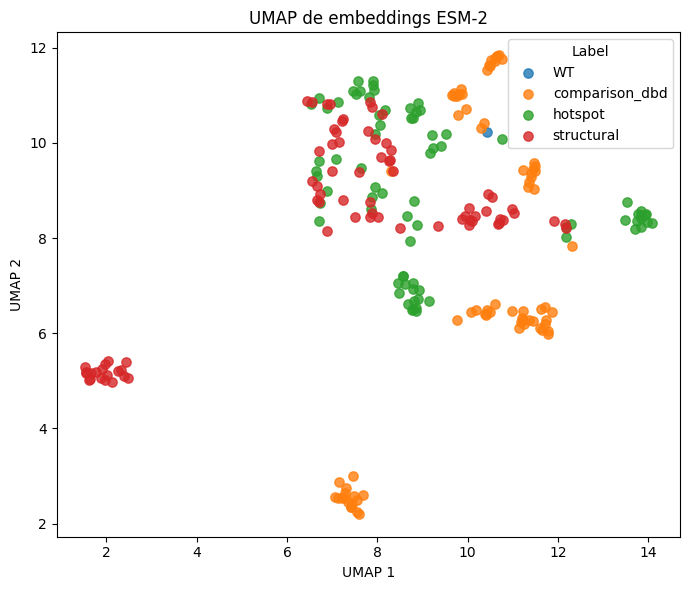

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

from sklearn.preprocessing import StandardScaler


# =========================
# 1. Revisar dimensiones
# =========================

X = global_emb
labels = group_list

print("Shape embeddings:", X.shape)
print("Número de labels:", len(labels))

assert X.shape[0] == len(labels), "El número de embeddings y labels no coincide"


# =========================
# 2. Escalar embeddings
# =========================

X_scaled = StandardScaler().fit_transform(X)


# =========================
# 3. Calcular UMAP
# =========================

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
)

X_umap = reducer.fit_transform(X_scaled)


# =========================
# 4. Pasar a dataframe
# =========================

df_umap = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "label": labels,
})


# =========================
# 5. Graficar por label
# =========================

plt.figure(figsize=(7, 6))

for label in np.unique(labels):
    subset = df_umap[df_umap["label"] == label]
    plt.scatter(
        subset["UMAP1"],
        subset["UMAP2"],
        label=label,
        alpha=0.8,
        s=45,
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP de embeddings ESM-2")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


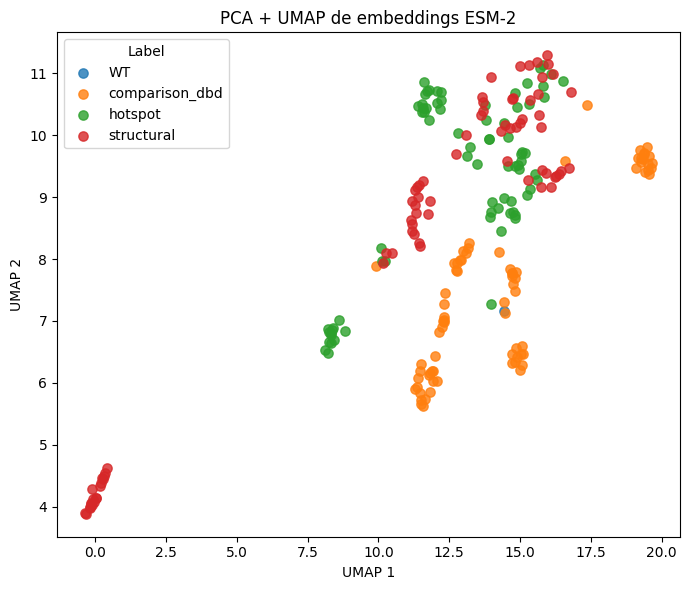

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap


X_scaled = StandardScaler().fit_transform(X)

X_pca = PCA(n_components=50, random_state=42).fit_transform(X_scaled)

X_umap = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
).fit_transform(X_pca)

# =========================
# 4. Pasar a dataframe
# =========================

df_umap = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "label": labels,
})


# =========================
# 5. Graficar por label
# =========================

plt.figure(figsize=(7, 6))

for label in np.unique(labels):
    subset = df_umap[df_umap["label"] == label]
    plt.scatter(
        subset["UMAP1"],
        subset["UMAP2"],
        label=label,
        alpha=0.8,
        s=45,
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("PCA + UMAP de embeddings ESM-2")
plt.legend(title="Label")
plt.tight_layout()
plt.show()


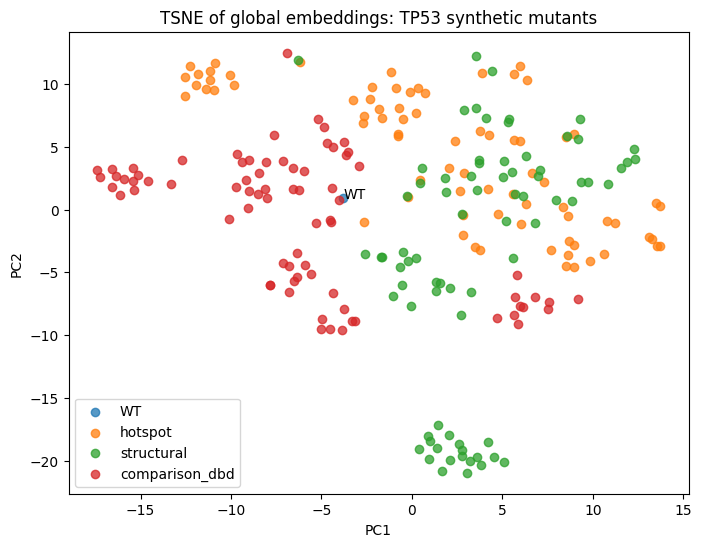

In [ ]:

from sklearn.manifold import TSNE

coords = TSNE(n_components=2).fit_transform(global_emb)

plot_df = pd.DataFrame({
    "label": labels,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "group": ["WT"] + [m["group"] for m in mutants]
})

plt.figure(figsize=(8, 6))
for g in ["WT", "hotspot", "structural", "comparison_dbd"]:
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.text(wt_row["PC1"], wt_row["PC2"], "WT", fontsize=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("TSNE of global embeddings: TP53 synthetic mutants")
plt.legend()
plt.savefig("pca-global-embeddings.svg")
plt.show()

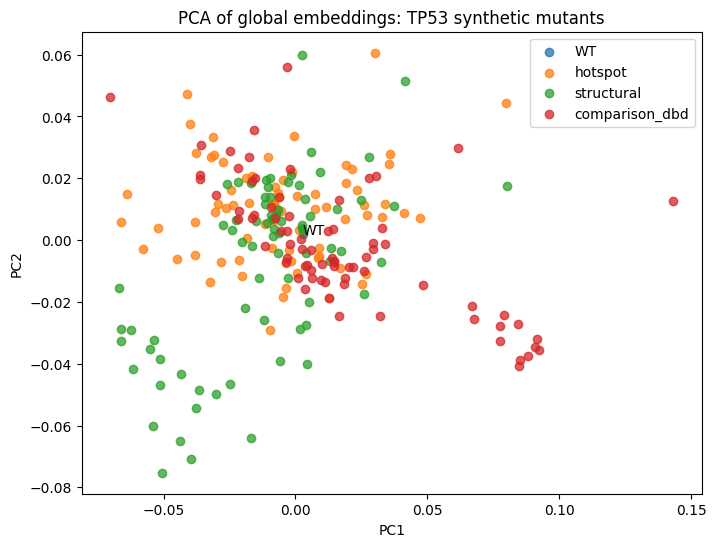

In [ ]:
pca = PCA(n_components=2)
coords = pca.fit_transform(global_emb)

plot_df = pd.DataFrame({
    "label": labels,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "group": ["WT"] + [m["group"] for m in mutants]
})

plt.figure(figsize=(8, 6))
for g in ["WT", "hotspot", "structural", "comparison_dbd"]:
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.text(wt_row["PC1"], wt_row["PC2"], "WT", fontsize=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of global embeddings: TP53 synthetic mutants")
plt.legend()
plt.savefig("pca-global-embeddings.svg")
plt.show()

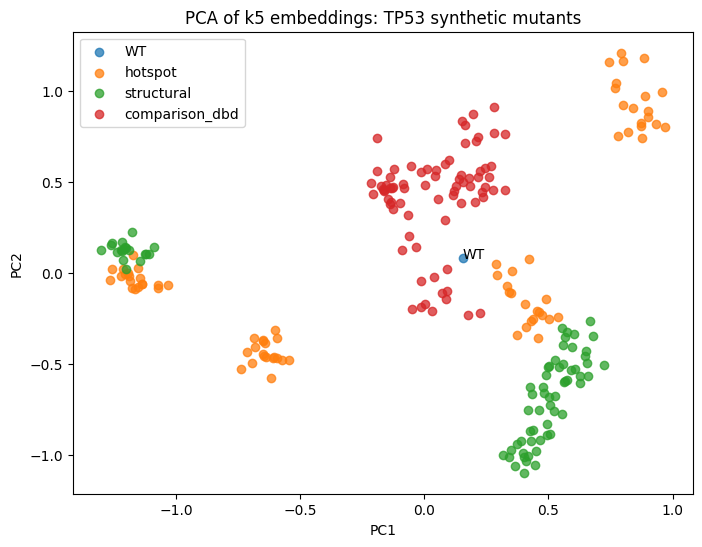

In [ ]:
## Proyeccion de k5

pca = PCA(n_components=2)
coords = pca.fit_transform(k5_emb)

plot_df = pd.DataFrame({
    "label": labels,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "group": ["WT"] + [m["group"] for m in mutants]
})

plt.figure(figsize=(8, 6))
for g in ["WT", "hotspot", "structural", "comparison_dbd"]:
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.text(wt_row["PC1"], wt_row["PC2"], "WT", fontsize=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of k5 embeddings: TP53 synthetic mutants")
plt.legend()
plt.savefig("pca-k5-embeddings.svg")
plt.show()

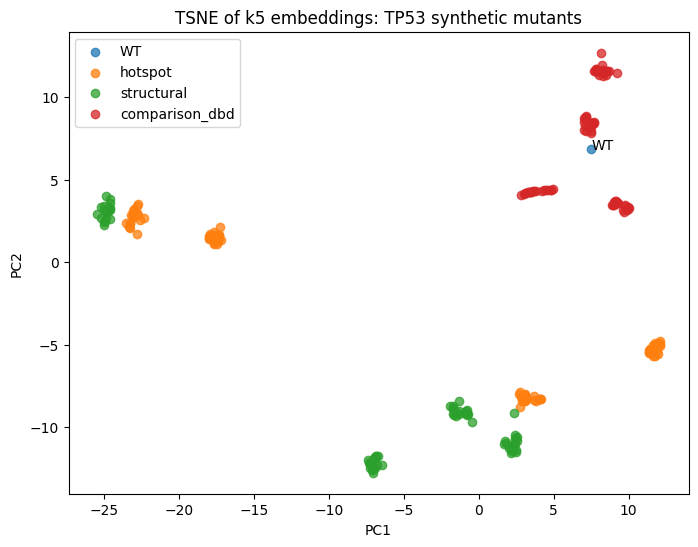

In [ ]:
coords = TSNE(n_components=2).fit_transform(k5_emb)

plot_df = pd.DataFrame({
    "label": labels,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "group": ["WT"] + [m["group"] for m in mutants]
})

plt.figure(figsize=(8, 6))
for g in ["WT", "hotspot", "structural", "comparison_dbd"]:
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.text(wt_row["PC1"], wt_row["PC2"], "WT", fontsize=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("TSNE of k5 embeddings: TP53 synthetic mutants")
plt.legend()
plt.savefig("tsne-k5-embeddings.svg")
plt.show()

In [ ]:

# =========================
# 1. Revisar dimensiones
# =========================

X = k5_emb
labels = group_list

print("Shape embeddings:", X.shape)
print("Número de labels:", len(labels))

assert X.shape[0] == len(labels), "El número de embeddings y labels no coincide"


# =========================
# 2. Escalar embeddings
# =========================

X_scaled = StandardScaler().fit_transform(X)


# =========================
# 3. Calcular UMAP
# =========================

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
)

X_umap = reducer.fit_transform(X_scaled)


# =========================
# 4. Pasar a dataframe
# =========================

df_umap = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "label": labels,
})


# =========================
# 5. Graficar por label
# =========================


Shape embeddings: (229, 320)
Número de labels: 229


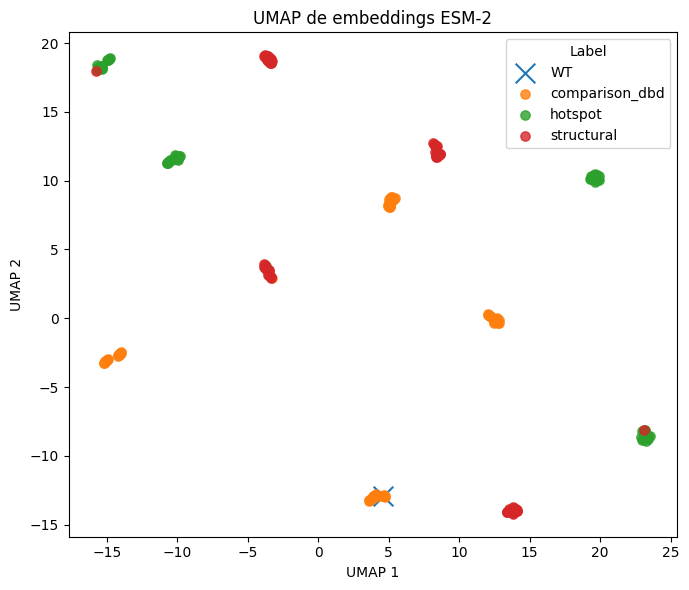

In [ ]:

plt.figure(figsize=(7, 6))

for label in np.unique(labels):
    subset = df_umap[df_umap["label"] == label]
    if label == "WT":
        plt.scatter(
            subset["UMAP1"],
            subset["UMAP2"],
            label=label,
            alpha=1.0,
            s=200,
            marker="x"
        )
    else:
      plt.scatter(
          subset["UMAP1"],
          subset["UMAP2"],
          label=label,
          alpha=0.8,
          s=45,
      )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP de embeddings ESM-2")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

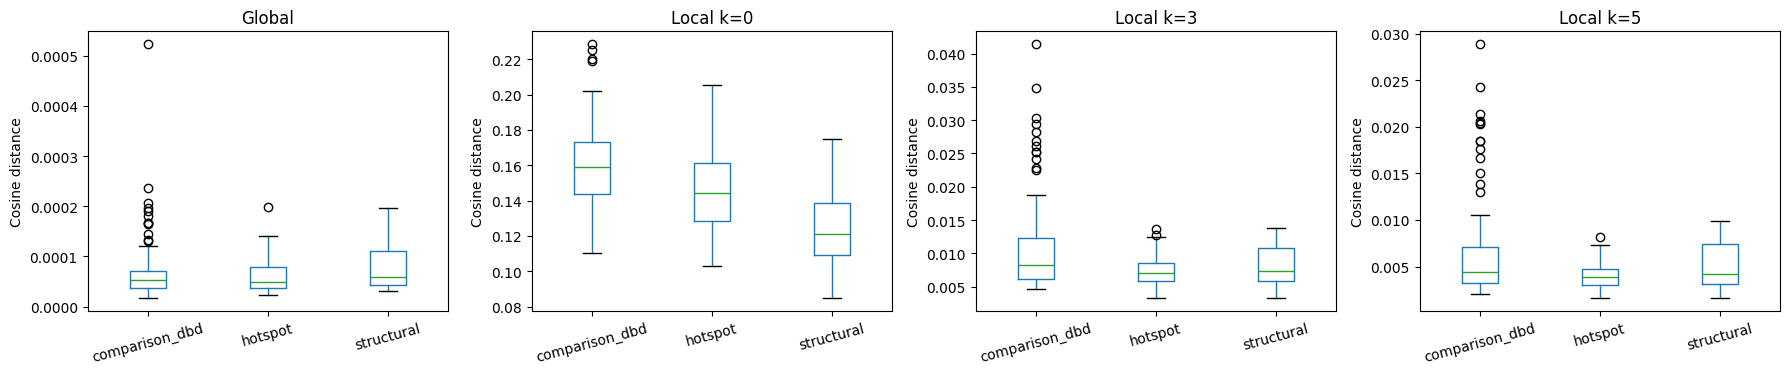

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

plot_map = [
    ("global_cosine_distance_to_WT", "Global"),
    ("k0_cosine_distance_to_WT", "Local k=0"),
    ("k3_cosine_distance_to_WT", "Local k=3"),
    ("k5_cosine_distance_to_WT", "Local k=5"),
]

for ax, (col, title) in zip(axes, plot_map):
    df.boxplot(column=col, by="group", grid=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Cosine distance")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("")
plt.tight_layout()
plt.show()

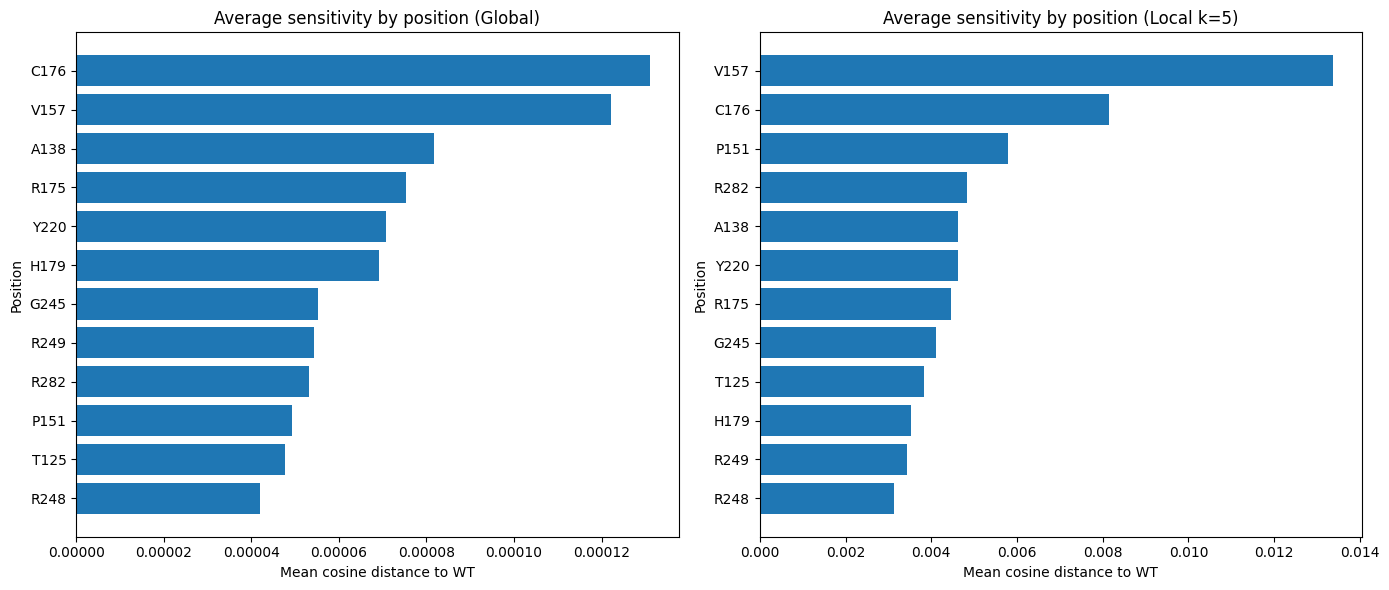

In [ ]:
rank_global = summary_by_position.sort_values("global_mean", ascending=False)[["site", "global_mean"]].reset_index(drop=True)
rank_k5 = summary_by_position.sort_values("k5_mean", ascending=False)[["site", "k5_mean"]].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tmp = summary_by_position.sort_values("global_mean", ascending=True)
axes[0].barh(tmp["site"], tmp["global_mean"])
axes[0].set_title("Average sensitivity by position (Global)")
axes[0].set_xlabel("Mean cosine distance to WT")
axes[0].set_ylabel("Position")

tmp = summary_by_position.sort_values("k5_mean", ascending=True)
axes[1].barh(tmp["site"], tmp["k5_mean"])
axes[1].set_title("Average sensitivity by position (Local k=5)")
axes[1].set_xlabel("Mean cosine distance to WT")
axes[1].set_ylabel("Position")

plt.tight_layout()
plt.savefig("average-sensitivity-by-position-global-vs-k5.svg")
plt.show()

In [ ]:
compare_rank = summary_by_position[["site", "group", "global_mean", "k5_mean"]].copy()
compare_rank["delta_k5_minus_global"] = compare_rank["k5_mean"] - compare_rank["global_mean"]
compare_rank = compare_rank.sort_values("delta_k5_minus_global", ascending=False)

compare_rank

,site,group,global_mean,k5_mean,delta_k5_minus_global
3,V157,comparison_dbd,0.000122,0.013381,0.013259
8,C176,structural,0.000131,0.008157,0.008026
2,P151,comparison_dbd,0.000049,0.005791,0.005741
11,R282,structural,0.000053,0.004841,0.004788
5,Y220,hotspot,0.000071,0.004625,0.004554
1,A138,comparison_dbd,0.000082,0.004635,0.004553
4,R175,hotspot,0.000075,0.004469,0.004393
6,G245,hotspot,0.000055,0.004102,0.004047
0,T125,comparison_dbd,0.000048,0.003842,0.003795
9,H179,structural,0.000069,0.003536,0.003467


In [ ]:
compare_rank.to_csv("compare_rank.csv", index=False)



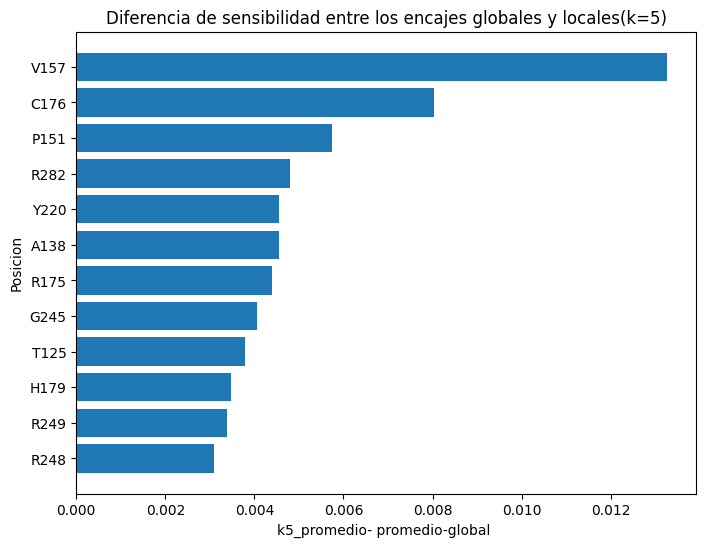

In [ ]:
tmp = compare_rank.sort_values("delta_k5_minus_global", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(tmp["site"], tmp["delta_k5_minus_global"])
plt.xlabel("k5_promedio- promedio-global ")
plt.ylabel("Posicion")
plt.title("Diferencia de sensibilidad entre los encajes globales y locales(k=5)")
plt.savefig("compare_rank.svg")
plt.show()

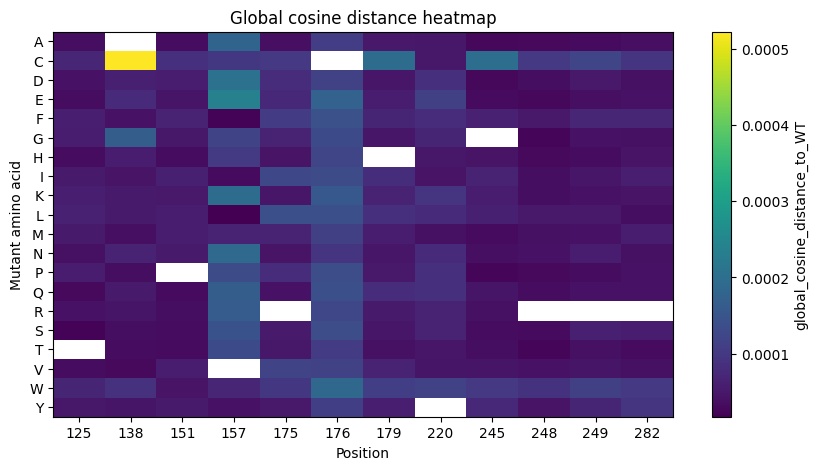

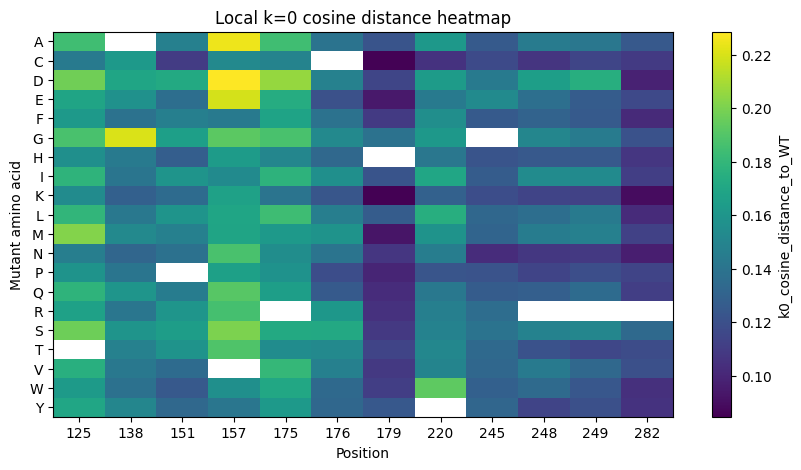

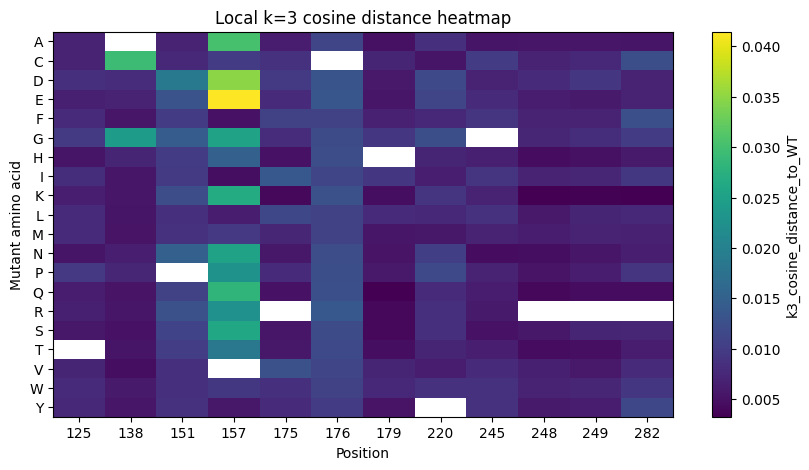

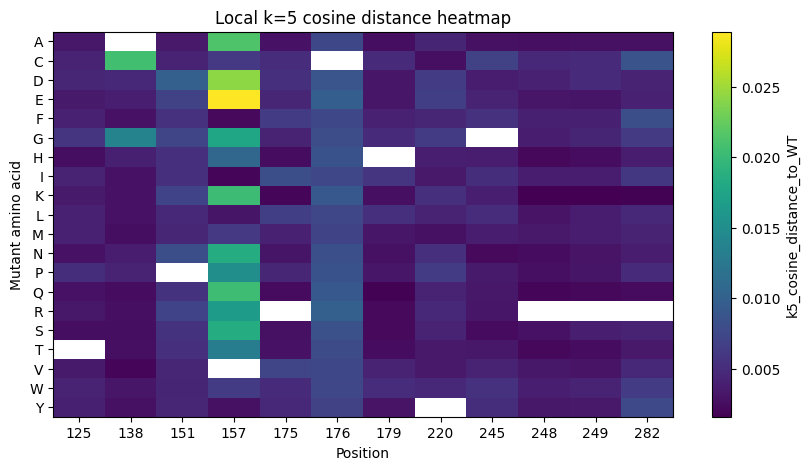

In [ ]:
def plot_heatmap(df, value_col, title):
    heat = df.pivot(index="mut_aa", columns="position", values=value_col)

    plt.figure(figsize=(10, 5))
    plt.imshow(heat.values, aspect="auto")
    plt.xticks(range(len(heat.columns)), heat.columns)
    plt.yticks(range(len(heat.index)), heat.index)
    plt.colorbar(label=value_col)
    plt.xlabel("Position")
    plt.ylabel("Mutant amino acid")
    plt.title(title)
    plt.show()

plot_heatmap(df, "global_cosine_distance_to_WT", "Global cosine distance heatmap")
plot_heatmap(df, "k0_cosine_distance_to_WT", "Local k=0 cosine distance heatmap")
plot_heatmap(df, "k3_cosine_distance_to_WT", "Local k=3 cosine distance heatmap")
plot_heatmap(df, "k5_cosine_distance_to_WT", "Local k=5 cosine distance heatmap")

In [ ]:
df.sort_values("k5_cosine_distance_to_WT", ascending=False)[
    [
        "mutant", "position", "group",
        "global_cosine_distance_to_WT",
        "k0_cosine_distance_to_WT",
        "k3_cosine_distance_to_WT",
        "k5_cosine_distance_to_WT",
    ]
].head(25)

,mutant,position,group,global_cosine_distance_to_WT,k0_cosine_distance_to_WT,k3_cosine_distance_to_WT,k5_cosine_distance_to_WT
212,V157E,157,comparison_dbd,0.000236,0.219216,0.041443,0.028881
211,V157D,157,comparison_dbd,0.000206,0.228609,0.034809,0.024297
209,V157A,157,comparison_dbd,0.000180,0.225121,0.030387,0.021405
171,A138C,138,comparison_dbd,0.000523,0.161888,0.029459,0.020641
222,V157Q,157,comparison_dbd,0.000166,0.191422,0.028227,0.020410
217,V157K,157,comparison_dbd,0.000196,0.166804,0.026817,0.020325
220,V157N,157,comparison_dbd,0.000190,0.187424,0.025252,0.018527
224,V157S,157,comparison_dbd,0.000145,0.199963,0.026082,0.018460
214,V157G,157,comparison_dbd,0.000121,0.192568,0.025293,0.017664
223,V157R,157,comparison_dbd,0.000164,0.185905,0.022593,0.016686


In [ ]:
df.to_csv("tp53_synthetic_mutants_embedding_metrics.csv", index=False)
summary_by_position.to_csv("tp53_position_summary_embedding_metrics.csv", index=False)

print("Saved:")
print("- tp53_synthetic_mutants_embedding_metrics.csv")
print("- tp53_position_summary_embedding_metrics.csv")

Saved:
- tp53_synthetic_mutants_embedding_metrics.csv
- tp53_position_summary_embedding_metrics.csv


## Revision de cargas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga neta simplificada
aa_charge = {
    "R": "positive", "K": "positive", "H": "positive",
    "D": "negative", "E": "negative",
    "A": "neutral", "C": "neutral", "F": "neutral", "G": "neutral",
    "I": "neutral", "L": "neutral", "M": "neutral", "N": "neutral",
    "P": "neutral", "Q": "neutral", "S": "neutral", "T": "neutral",
    "V": "neutral", "W": "neutral", "Y": "neutral"
}

# Clase fisicoquímica gruesa
aa_class = {
    "A": "hydrophobic", "V": "hydrophobic", "I": "hydrophobic",
    "L": "hydrophobic", "M": "hydrophobic", "F": "hydrophobic",
    "W": "hydrophobic", "Y": "hydrophobic",

    "S": "polar", "T": "polar", "N": "polar", "Q": "polar",
    "C": "polar", "G": "special", "P": "special",

    "D": "charged", "E": "charged", "K": "charged",
    "R": "charged", "H": "charged"
}

# Tamaño aproximado
aa_size = {
    "G": "small", "A": "small", "S": "small", "C": "small",
    "D": "medium", "P": "medium", "N": "medium", "T": "medium",
    "E": "medium", "V": "medium", "Q": "medium", "H": "medium",
    "I": "large", "L": "large", "M": "large", "K": "large",
    "R": "large", "F": "large", "Y": "large", "W": "large"
}

aromatic = {"F", "W", "Y"}
aliphatic = {"A", "V", "I", "L", "M"}
polar = {"S", "T", "N", "Q", "C"}
charged = {"D", "E", "K", "R", "H"}

def annotate_mutation_type(df):
    df = df.copy()

    # Propiedades WT y MUT
    df["wt_charge"] = df["wt_aa"].map(aa_charge)
    df["mut_charge"] = df["mut_aa"].map(aa_charge)

    df["wt_class"] = df["wt_aa"].map(aa_class)
    df["mut_class"] = df["mut_aa"].map(aa_class)

    df["wt_size"] = df["wt_aa"].map(aa_size)
    df["mut_size"] = df["mut_aa"].map(aa_size)

    # Cambios binarios
    df["charge_change"] = df["wt_charge"] != df["mut_charge"]
    df["class_change"] = df["wt_class"] != df["mut_class"]
    df["size_change"] = df["wt_size"] != df["mut_size"]

    # Casos especiales
    df["introduces_proline"] = df["mut_aa"] == "P"
    df["introduces_glycine"] = df["mut_aa"] == "G"
    df["introduces_cysteine"] = df["mut_aa"] == "C"

    df["removes_proline"] = df["wt_aa"] == "P"
    df["removes_glycine"] = df["wt_aa"] == "G"
    df["removes_cysteine"] = df["wt_aa"] == "C"

    # Aromaticidad
    df["wt_aromatic"] = df["wt_aa"].isin(aromatic)
    df["mut_aromatic"] = df["mut_aa"].isin(aromatic)
    df["aromatic_change"] = df["wt_aromatic"] != df["mut_aromatic"]

    # Hidrofobicidad gruesa
    def hydro_group(aa):
        if aa in aliphatic or aa in aromatic:
            return "hydrophobic"
        elif aa in polar:
            return "polar"
        elif aa in charged:
            return "charged"
        elif aa in {"G", "P"}:
            return "special"
        else:
            return "other"

    df["wt_hydro_group"] = df["wt_aa"].map(hydro_group)
    df["mut_hydro_group"] = df["mut_aa"].map(hydro_group)
    df["hydro_group_change"] = df["wt_hydro_group"] != df["mut_hydro_group"]

    # Etiqueta resumida de conservatividad gruesa
    df["is_conservative_like"] = (
        (~df["charge_change"]) &
        (~df["class_change"]) &
        (~df["size_change"])
    )

    return df

df_annot = annotate_mutation_type(df)
df_annot.head()

,mutant,position,wt_aa,mut_aa,group,global_cosine_similarity_to_WT,global_cosine_distance_to_WT,global_euclidean_distance_to_WT,k0_cosine_similarity_to_WT,k0_cosine_distance_to_WT,...,removes_proline,removes_glycine,removes_cysteine,wt_aromatic,mut_aromatic,aromatic_change,wt_hydro_group,mut_hydro_group,hydro_group_change,is_conservative_like
0,R175A,175,R,A,hotspot,0.999962,0.000038,0.048010,0.815292,0.184708,...,False,False,False,False,False,False,charged,hydrophobic,True,False
1,R175C,175,R,C,hotspot,0.999900,0.000100,0.077952,0.850809,0.149191,...,False,False,False,False,False,False,charged,polar,True,False
2,R175D,175,R,D,hotspot,0.999918,0.000082,0.071097,0.794374,0.205626,...,False,False,False,False,False,False,charged,charged,False,False
3,R175E,175,R,E,hotspot,0.999925,0.000075,0.067498,0.826306,0.173694,...,False,False,False,False,False,False,charged,charged,False,False
4,R175F,175,R,F,hotspot,0.999895,0.000105,0.079686,0.831564,0.168436,...,False,False,False,False,True,True,charged,hydrophobic,True,False


In [ ]:
summary_flags = {
    "charge_change": df_annot["charge_change"].value_counts(),
    "class_change": df_annot["class_change"].value_counts(),
    "size_change": df_annot["size_change"].value_counts(),
    "hydro_group_change": df_annot["hydro_group_change"].value_counts(),
    "introduces_proline": df_annot["introduces_proline"].value_counts(),
    "introduces_glycine": df_annot["introduces_glycine"].value_counts(),
    "introduces_cysteine": df_annot["introduces_cysteine"].value_counts(),
    "aromatic_change": df_annot["aromatic_change"].value_counts(),
    "is_conservative_like": df_annot["is_conservative_like"].value_counts(),
}

for k, v in summary_flags.items():
    print("=" * 60)
    print(k)
    print(v)

charge_change
charge_change
True     120
False    108
Name: count, dtype: int64
class_change
class_change
True     177
False     51
Name: count, dtype: int64
size_change
size_change
True     156
False     72
Name: count, dtype: int64
hydro_group_change
hydro_group_change
True     177
False     51
Name: count, dtype: int64
introduces_proline
introduces_proline
False    217
True      11
Name: count, dtype: int64
introduces_glycine
introduces_glycine
False    217
True      11
Name: count, dtype: int64
introduces_cysteine
introduces_cysteine
False    217
True      11
Name: count, dtype: int64
aromatic_change
aromatic_change
False    178
True      50
Name: count, dtype: int64
is_conservative_like
is_conservative_like
False    216
True      12
Name: count, dtype: int64


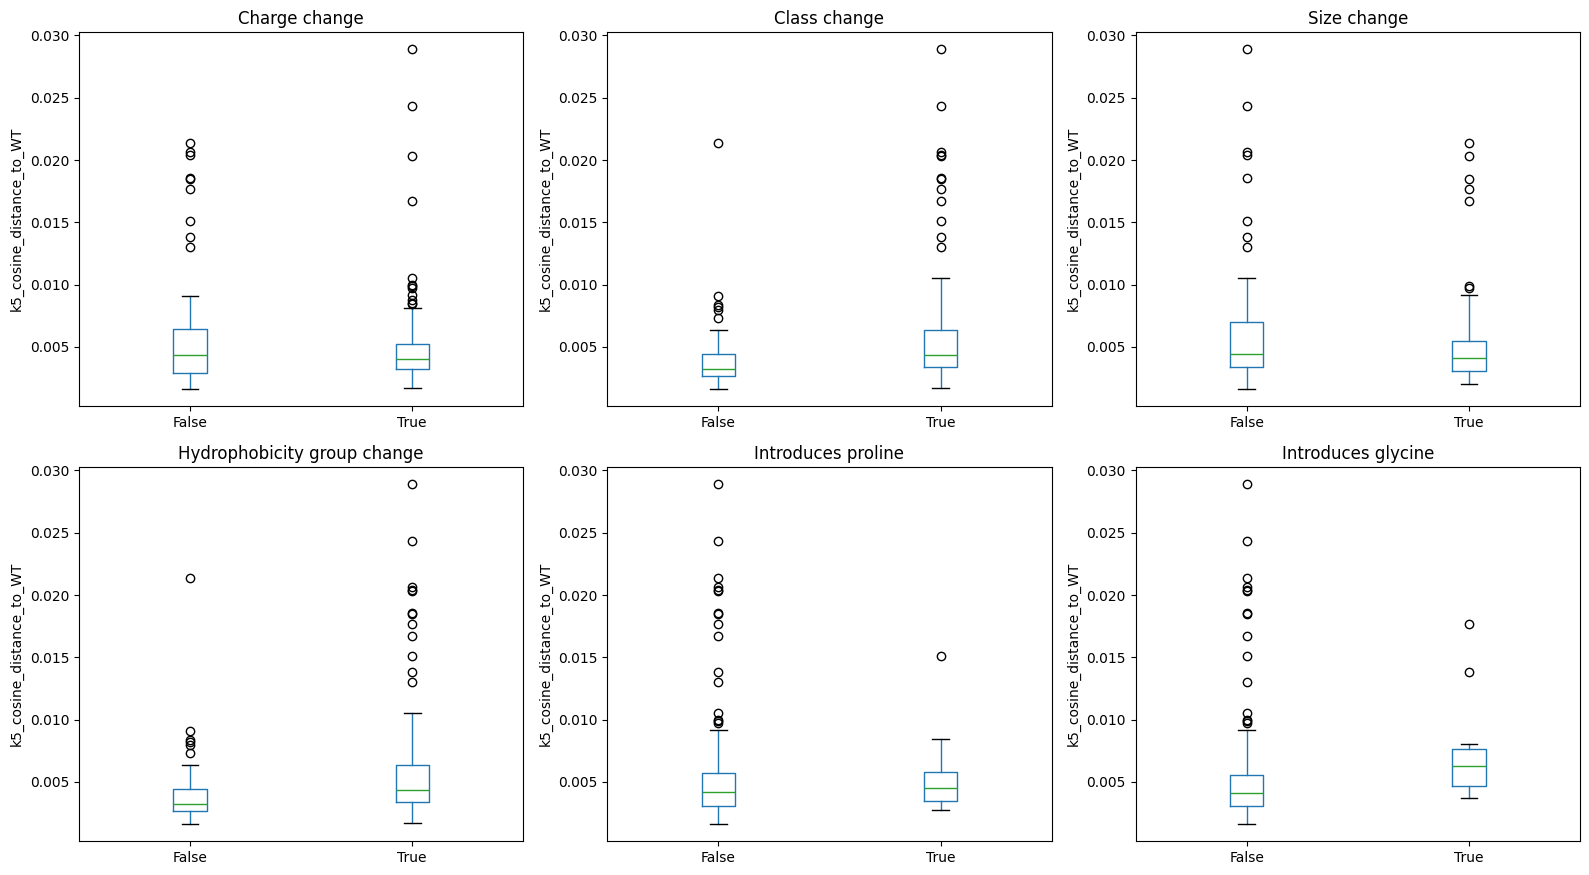

In [ ]:
metric = "k5_cosine_distance_to_WT"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plot_specs = [
    ("charge_change", "Charge change"),
    ("class_change", "Class change"),
    ("size_change", "Size change"),
    ("hydro_group_change", "Hydrophobicity group change"),
    ("introduces_proline", "Introduces proline"),
    ("introduces_glycine", "Introduces glycine"),
]

for ax, (col, title) in zip(axes.flatten(), plot_specs):
    df_annot.boxplot(column=metric, by=col, grid=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("")
plt.tight_layout()
plt.savefig("boxplot-categories-vs-k5-cosine-distance.svg")
plt.show()

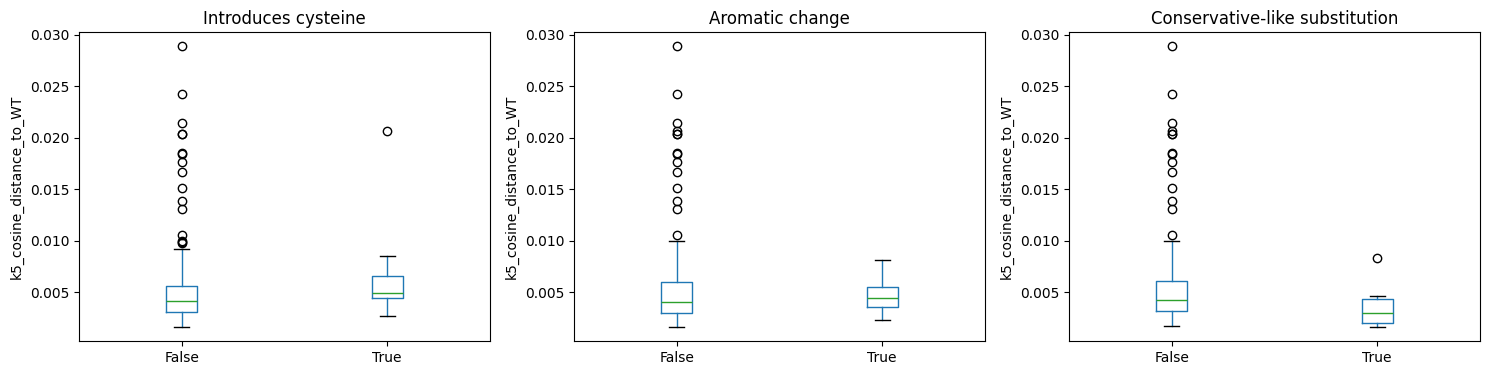

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

extra_specs = [
    ("introduces_cysteine", "Introduces cysteine"),
    ("aromatic_change", "Aromatic change"),
    ("is_conservative_like", "Conservative-like substitution"),
]

for ax, (col, title) in zip(axes.flatten(), extra_specs):
    df_annot.boxplot(column=metric, by=col, grid=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric)

plt.suptitle("")
plt.tight_layout()
plt.savefig("boxplot-categories-vs-k5-cosine-distance2.svg")
plt.show()

In [ ]:
def summarize_by_flag(df, flag_col, metric_col="k5_cosine_distance_to_WT"):
    out = (
        df.groupby(flag_col)[metric_col]
          .agg(["count", "mean", "median", "std", "max"])
          .reset_index()
          .sort_values("mean", ascending=False)
    )
    out["flag"] = flag_col
    return out

summary_tables = []
for col in [
    "charge_change",
    "class_change",
    "size_change",
    "hydro_group_change",
    "introduces_proline",
    "introduces_glycine",
    "introduces_cysteine",
    "aromatic_change",
    "is_conservative_like",
]:
    summary_tables.append(summarize_by_flag(df_annot, col, metric))

summary_flags_df = pd.concat(summary_tables, ignore_index=True)
summary_flags_df

,charge_change,count,mean,median,std,max,flag,class_change,size_change,hydro_group_change,introduces_proline,introduces_glycine,introduces_cysteine,aromatic_change,is_conservative_like
0,False,108,0.005593,0.004331,0.004163,0.021405,charge_change,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,True,120,0.005092,0.004053,0.003849,0.028881,charge_change,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,177,0.005667,0.004354,0.004180,0.028881,class_change,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,51,0.004155,0.003221,0.003051,0.021405,class_change,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,72,0.006254,0.004441,0.005324,0.028881,size_change,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,156,0.004902,0.004143,0.003141,0.021405,size_change,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,177,0.005667,0.004354,0.004180,0.028881,hydro_group_change,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN
7,NaN,51,0.004155,0.003221,0.003051,0.021405,hydro_group_change,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
8,NaN,11,0.005588,0.004482,0.003554,0.015084,introduces_proline,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN
9,NaN,217,0.005316,0.004171,0.004028,0.028881,introduces_proline,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN


In [ ]:
cols_to_show = [
    "mutant", "position", "group",
    "wt_aa", "mut_aa",
    "k5_cosine_distance_to_WT",
    "charge_change", "class_change", "size_change",
    "introduces_proline", "introduces_glycine", "introduces_cysteine",
    "aromatic_change", "is_conservative_like"
]

print("Top mutantes que introducen prolina")
display(
    df_annot[df_annot["introduces_proline"]]
    .sort_values("k5_cosine_distance_to_WT", ascending=False)[cols_to_show]
    .head(15)
)

print("Top mutantes que introducen glicina")
display(
    df_annot[df_annot["introduces_glycine"]]
    .sort_values("k5_cosine_distance_to_WT", ascending=False)[cols_to_show]
    .head(15)
)

print("Top mutantes conservativas-like")
display(
    df_annot[df_annot["is_conservative_like"]]
    .sort_values("k5_cosine_distance_to_WT", ascending=False)[cols_to_show]
    .head(15)
)

Top mutantes que introducen prolina


,mutant,position,group,wt_aa,mut_aa,k5_cosine_distance_to_WT,charge_change,class_change,size_change,introduces_proline,introduces_glycine,introduces_cysteine,aromatic_change,is_conservative_like
221,V157P,157,comparison_dbd,V,P,0.015084,False,True,False,True,False,False,False,False
87,C176P,176,structural,C,P,0.008483,False,True,True,True,False,False,False,False
31,Y220P,220,hotspot,Y,P,0.006392,False,True,True,True,False,False,True,False
164,T125P,125,comparison_dbd,T,P,0.005159,False,True,False,True,False,False,False,False
145,R282P,282,structural,R,P,0.004919,True,True,True,True,False,False,False,False
12,R175P,175,hotspot,R,P,0.004482,True,True,True,True,False,False,False,False
182,A138P,138,comparison_dbd,A,P,0.004186,False,True,True,True,False,False,False,False
49,G245P,245,hotspot,G,P,0.003575,False,False,True,True,False,False,False,False
106,H179P,179,structural,H,P,0.003300,True,True,False,True,False,False,False,False
126,R249P,249,structural,R,P,0.003120,True,True,True,True,False,False,False,False


Top mutantes que introducen glicina


,mutant,position,group,wt_aa,mut_aa,k5_cosine_distance_to_WT,charge_change,class_change,size_change,introduces_proline,introduces_glycine,introduces_cysteine,aromatic_change,is_conservative_like
214,V157G,157,comparison_dbd,V,G,0.017664,False,True,True,False,True,False,False,False
175,A138G,138,comparison_dbd,A,G,0.013841,False,True,False,False,True,False,False,False
80,C176G,176,structural,C,G,0.008030,False,True,False,False,True,False,False,False
195,P151G,151,comparison_dbd,P,G,0.007309,False,False,True,False,True,False,False,False
24,Y220G,220,hotspot,Y,G,0.006440,False,True,True,False,True,False,True,False
138,R282G,282,structural,R,G,0.006278,True,True,True,False,True,False,False,False
157,T125G,125,comparison_dbd,T,G,0.005657,False,True,True,False,True,False,False,False
100,H179G,179,structural,H,G,0.004951,True,True,True,False,True,False,False,False
119,R249G,249,structural,R,G,0.004380,True,True,True,False,True,False,False,False
5,R175G,175,hotspot,R,G,0.004329,True,True,True,False,True,False,False,False


Top mutantes conservativas-like


,mutant,position,group,wt_aa,mut_aa,k5_cosine_distance_to_WT,charge_change,class_change,size_change,introduces_proline,introduces_glycine,introduces_cysteine,aromatic_change,is_conservative_like
90,C176S,176,structural,C,S,0.008329,False,False,False,False,False,False,False,True
37,Y220W,220,hotspot,Y,W,0.004673,False,False,False,False,False,False,False,True
23,Y220F,220,hotspot,Y,F,0.004527,False,False,False,False,False,False,False,True
28,Y220L,220,hotspot,Y,L,0.004292,False,False,False,False,False,False,True,True
26,Y220I,220,hotspot,Y,I,0.003422,False,False,False,False,False,False,True,True
165,T125Q,125,comparison_dbd,T,Q,0.002980,False,False,False,False,False,False,False,True
163,T125N,125,comparison_dbd,T,N,0.002953,False,False,False,False,False,False,False,True
29,Y220M,220,hotspot,Y,M,0.002829,False,False,False,False,False,False,True,True
8,R175K,175,hotspot,R,K,0.002113,False,False,False,False,False,False,False,True
141,R282K,282,structural,R,K,0.001789,False,False,False,False,False,False,False,True


In [ ]:
df_annot.to_csv("tp53_synthetic_mutants_embedding_metrics_annotated.csv", index=False)
summary_flags_df.to_csv("tp53_mutation_type_summary_k5.csv", index=False)

print("Saved:")
print("- tp53_synthetic_mutants_embedding_metrics_annotated.csv")
print("- tp53_mutation_type_summary_k5.csv")

Saved:
- tp53_synthetic_mutants_embedding_metrics_annotated.csv
- tp53_mutation_type_summary_k5.csv


## Pruebas estadisticas


In [ ]:
!pip -q install scipy statsmodels

In [ ]:
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

In [ ]:
metric = "k5_cosine_distance_to_WT"

flag_cols = [
    "charge_change",
    "class_change",
    "size_change",
    "hydro_group_change",
    "introduces_proline",
    "introduces_glycine",
    "introduces_cysteine",
    "aromatic_change",
    "is_conservative_like",
]

df_annot[flag_cols + [metric]].head()

,charge_change,class_change,size_change,hydro_group_change,introduces_proline,introduces_glycine,introduces_cysteine,aromatic_change,is_conservative_like,k5_cosine_distance_to_WT
0,True,True,True,True,False,False,False,False,False,0.002931
1,True,True,True,True,False,False,True,False,False,0.005104
2,True,False,True,False,False,False,False,False,False,0.005405
3,True,False,True,False,False,False,False,False,False,0.004501
4,True,True,False,True,False,False,False,True,False,0.006403


In [ ]:
def mann_whitney_for_flag(df, flag_col, metric_col):
    sub = df[[flag_col, metric_col]].dropna().copy()

    x_false = sub.loc[sub[flag_col] == False, metric_col].values
    x_true  = sub.loc[sub[flag_col] == True,  metric_col].values

    n_false = len(x_false)
    n_true = len(x_true)

    if n_false == 0 or n_true == 0:
        return {
            "flag": flag_col,
            "n_false": n_false,
            "n_true": n_true,
            "mean_false": np.nan,
            "mean_true": np.nan,
            "median_false": np.nan,
            "median_true": np.nan,
            "median_diff_true_minus_false": np.nan,
            "u_stat": np.nan,
            "p_value": np.nan,
            "rank_biserial": np.nan,
        }

    # Mann–Whitney U, dos colas
    u_stat, p_value = mannwhitneyu(x_true, x_false, alternative="two-sided")

    # Rank-biserial correlation
    # RBC = 2U/(n1*n2) - 1, usando U del grupo "true"
    rank_biserial = (2 * u_stat) / (n_true * n_false) - 1

    return {
        "flag": flag_col,
        "n_false": n_false,
        "n_true": n_true,
        "mean_false": float(np.mean(x_false)),
        "mean_true": float(np.mean(x_true)),
        "median_false": float(np.median(x_false)),
        "median_true": float(np.median(x_true)),
        "median_diff_true_minus_false": float(np.median(x_true) - np.median(x_false)),
        "u_stat": float(u_stat),
        "p_value": float(p_value),
        "rank_biserial": float(rank_biserial),
    }

In [ ]:
mw_results = pd.DataFrame(
    [mann_whitney_for_flag(df_annot, col, metric) for col in flag_cols]
)

# Corrección Benjamini–Hochberg
valid_mask = mw_results["p_value"].notna()
rej, p_adj, _, _ = multipletests(
    mw_results.loc[valid_mask, "p_value"].values,
    alpha=0.05,
    method="fdr_bh"
)

mw_results.loc[valid_mask, "p_adj_bh"] = p_adj
mw_results.loc[valid_mask, "significant_bh_0_05"] = rej

mw_results = mw_results.sort_values("p_adj_bh", ascending=True)
mw_results

,flag,n_false,n_true,mean_false,mean_true,median_false,median_true,median_diff_true_minus_false,u_stat,p_value,rank_biserial,p_adj_bh,significant_bh_0_05
1,class_change,51,177,0.004155,0.005667,0.003221,0.004354,0.001132,6110.0,0.000120,0.353717,0.000542,True
3,hydro_group_change,51,177,0.004155,0.005667,0.003221,0.004354,0.001132,6110.0,0.000120,0.353717,0.000542,True
5,introduces_glycine,217,11,0.005219,0.007507,0.004130,0.006278,0.002148,1777.0,0.006303,0.488898,0.018909,True
8,is_conservative_like,216,12,0.005434,0.003432,0.004241,0.002966,-0.001275,755.0,0.015088,-0.417438,0.033949,True
6,introduces_cysteine,217,11,0.005263,0.006637,0.004130,0.004925,0.000795,1584.0,0.067654,0.327189,0.121777,False
2,size_change,72,156,0.006254,0.004902,0.004441,0.004143,-0.000297,4924.0,0.135278,-0.123219,0.202917,False
7,aromatic_change,178,50,0.005492,0.004750,0.004096,0.004395,0.000300,4961.0,0.215449,0.114831,0.277005,False
0,charge_change,108,120,0.005593,0.005092,0.004331,0.004053,-0.000279,6128.0,0.479692,-0.054321,0.520938,False
4,introduces_proline,217,11,0.005316,0.005588,0.004171,0.004482,0.000312,1331.0,0.520938,0.115207,0.520938,False


In [ ]:
mw_display = mw_results.copy()

for col in [
    "mean_false", "mean_true",
    "median_false", "median_true",
    "median_diff_true_minus_false",
    "rank_biserial",
    "p_value", "p_adj_bh"
]:
    mw_display[col] = mw_display[col].round(6)

mw_display

,flag,n_false,n_true,mean_false,mean_true,median_false,median_true,median_diff_true_minus_false,u_stat,p_value,rank_biserial,p_adj_bh,significant_bh_0_05
1,class_change,51,177,0.004155,0.005667,0.003221,0.004354,0.001132,6110.0,0.000120,0.353717,0.000542,True
3,hydro_group_change,51,177,0.004155,0.005667,0.003221,0.004354,0.001132,6110.0,0.000120,0.353717,0.000542,True
5,introduces_glycine,217,11,0.005219,0.007507,0.004130,0.006278,0.002148,1777.0,0.006303,0.488898,0.018909,True
8,is_conservative_like,216,12,0.005434,0.003432,0.004241,0.002966,-0.001275,755.0,0.015088,-0.417438,0.033949,True
6,introduces_cysteine,217,11,0.005263,0.006637,0.004130,0.004925,0.000795,1584.0,0.067654,0.327189,0.121777,False
2,size_change,72,156,0.006254,0.004902,0.004441,0.004143,-0.000297,4924.0,0.135278,-0.123219,0.202917,False
7,aromatic_change,178,50,0.005492,0.004750,0.004096,0.004395,0.000300,4961.0,0.215449,0.114831,0.277005,False
0,charge_change,108,120,0.005593,0.005092,0.004331,0.004053,-0.000279,6128.0,0.479692,-0.054321,0.520938,False
4,introduces_proline,217,11,0.005316,0.005588,0.004171,0.004482,0.000312,1331.0,0.520938,0.115207,0.520938,False


In [ ]:
def interpret_rbc(rbc):
    a = abs(rbc)
    if a < 0.1:
        return "very small"
    elif a < 0.3:
        return "small"
    elif a < 0.5:
        return "moderate"
    else:
        return "large"

mw_interpret = mw_results.copy()
mw_interpret["effect_size_label"] = mw_interpret["rank_biserial"].apply(
    lambda x: interpret_rbc(x) if pd.notna(x) else np.nan
)

mw_interpret[[
    "flag",
    "median_false",
    "median_true",
    "median_diff_true_minus_false",
    "rank_biserial",
    "effect_size_label",
    "p_value",
    "p_adj_bh",
    "significant_bh_0_05",
]].sort_values("p_adj_bh")

,flag,median_false,median_true,median_diff_true_minus_false,rank_biserial,effect_size_label,p_value,p_adj_bh,significant_bh_0_05
1,class_change,0.003221,0.004354,0.001132,0.353717,moderate,0.000120,0.000542,True
3,hydro_group_change,0.003221,0.004354,0.001132,0.353717,moderate,0.000120,0.000542,True
5,introduces_glycine,0.004130,0.006278,0.002148,0.488898,moderate,0.006303,0.018909,True
8,is_conservative_like,0.004241,0.002966,-0.001275,-0.417438,moderate,0.015088,0.033949,True
6,introduces_cysteine,0.004130,0.004925,0.000795,0.327189,moderate,0.067654,0.121777,False
2,size_change,0.004441,0.004143,-0.000297,-0.123219,small,0.135278,0.202917,False
7,aromatic_change,0.004096,0.004395,0.000300,0.114831,small,0.215449,0.277005,False
0,charge_change,0.004331,0.004053,-0.000279,-0.054321,very small,0.479692,0.520938,False
4,introduces_proline,0.004171,0.004482,0.000312,0.115207,small,0.520938,0.520938,False


In [ ]:

mw_interpret.to_csv("mannwhitney_k5_results.csv", index=False, encoding='utf-8')
print("Saved: mannwhitney_k5_results.csv")

Saved: mannwhitney_k5_results.csv


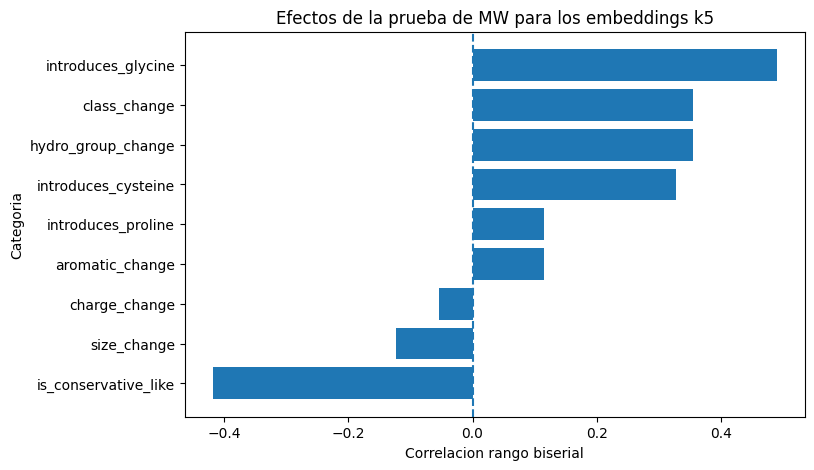

In [ ]:
import matplotlib.pyplot as plt

tmp = mw_results.sort_values("rank_biserial", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(tmp["flag"], tmp["rank_biserial"])
plt.axvline(0, linestyle="--")
plt.xlabel("Correlacion rango biserial")
plt.ylabel("Categoria")
plt.title(f"Efectos de la prueba de MW para los embeddings k5")
plt.savefig("mannwhitney-effect-sizes-k5-cosine.svg")
plt.show()

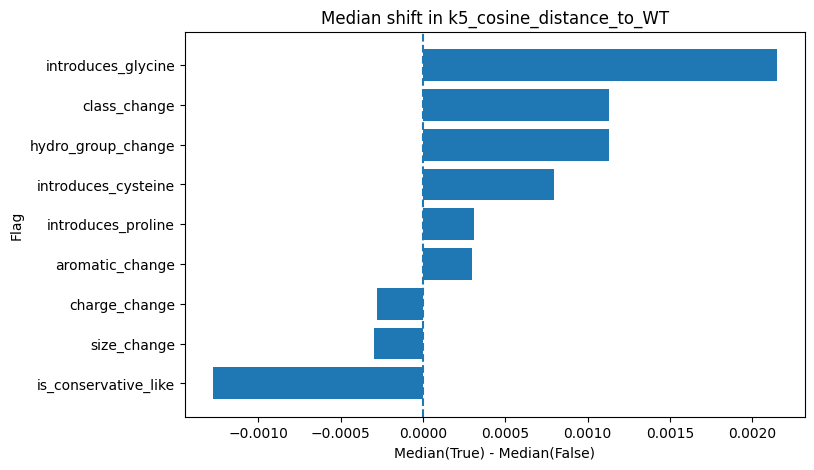

In [ ]:
tmp = mw_results.copy()
tmp["median_true_minus_false"] = tmp["median_true"] - tmp["median_false"]
tmp = tmp.sort_values("median_true_minus_false", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(tmp["flag"], tmp["median_true_minus_false"])
plt.axvline(0, linestyle="--")
plt.xlabel("Median(True) - Median(False)")
plt.ylabel("Flag")
plt.title(f"Median shift in {metric}")
plt.savefig("median-shift-k5-cosine.svg")
plt.show()

In [ ]:
mw_results.to_csv("tp53_mannwhitney_k5_results.csv", index=False)
print("Saved: tp53_mannwhitney_k5_results.csv")

Saved: tp53_mannwhitney_k5_results.csv


#FASE 2


In [ ]:
!pip -q install requests scipy statsmodels

In [ ]:
import io
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr, mannwhitneyu

In [ ]:
# Score set recomendado para empezar
MAVEDB_URN = "urn:mavedb:00000068-0-1"

base = "https://api.mavedb.org/api/v1"
url_scores = f"{base}/score-sets/{MAVEDB_URN}/scores"
url_meta = f"{base}/score-sets/{MAVEDB_URN}"

meta = requests.get(url_meta, timeout=60)
meta.raise_for_status()
meta_json = meta.json()

scores = requests.get(url_scores, timeout=60)
scores.raise_for_status()

mave_raw = pd.read_csv(io.StringIO(scores.text))

print("Title:", meta_json.get("title", "N/A"))
print("URN:", MAVEDB_URN)
print("Shape:", mave_raw.shape)
print("\nColumns:")
print(list(mave_raw.columns))
display(mave_raw.head())

Title: Combined score using three assays of TP53 activity that assess loss of function or dominant negative effect
URN: urn:mavedb:00000068-0-1
Shape: (8258, 5)

Columns:
['accession', 'hgvs_nt', 'hgvs_splice', 'hgvs_pro', 'score']


,accession,hgvs_nt,hgvs_splice,hgvs_pro,score
0,urn:mavedb:00000068-0-1#1,NaN,NaN,p.Met1Ala,-0.450940
1,urn:mavedb:00000068-0-1#2,NaN,NaN,p.Met1Cys,-0.193730
2,urn:mavedb:00000068-0-1#3,NaN,NaN,p.Met1Asp,-0.340391
3,urn:mavedb:00000068-0-1#4,NaN,NaN,p.Met1Glu,-1.176049
4,urn:mavedb:00000068-0-1#5,NaN,NaN,p.Met1Phe,-0.340391


In [ ]:
def pick_first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

variant_candidates = [
    "hgvs_pro", "hgvs_p", "protein_variant", "variant",
    "aa_variant", "amino_acid_change", "protein_change"
]

score_candidates = [
    "score", "main_score", "functional_score",
    "score_value", "normalized_score"
]

variant_col = pick_first_existing(mave_raw.columns, variant_candidates)
score_col = pick_first_existing(mave_raw.columns, score_candidates)

print("Auto-detected variant_col:", variant_col)
print("Auto-detected score_col:", score_col)

if variant_col is None:
    print("\nNo pude detectar automáticamente la columna de variante.")
    print("Columnas disponibles:")
    print(list(mave_raw.columns))

if score_col is None:
    print("\nNo pude detectar automáticamente la columna de score.")
    numeric_cols = [c for c in mave_raw.columns if pd.api.types.is_numeric_dtype(mave_raw[c])]
    print("Columnas numéricas candidatas:")
    print(numeric_cols)

Auto-detected variant_col: hgvs_pro
Auto-detected score_col: score


In [ ]:
aa3_to_aa1 = {
    "Ala": "A", "Arg": "R", "Asn": "N", "Asp": "D", "Cys": "C",
    "Gln": "Q", "Glu": "E", "Gly": "G", "His": "H", "Ile": "I",
    "Leu": "L", "Lys": "K", "Met": "M", "Phe": "F", "Pro": "P",
    "Ser": "S", "Thr": "T", "Trp": "W", "Tyr": "Y", "Val": "V",
    "Ter": "*", "Stop": "*"
}

def normalize_protein_variant(x):
    if pd.isna(x):
        return None

    s = str(x).strip()

    # quitar prefijo p.
    s = re.sub(r"^p\.", "", s)

    # Caso 1: una letra, p. R175H
    m1 = re.match(r"^([A-Z\*])(\d+)([A-Z\*])$", s)
    if m1:
        wt, pos, mut = m1.groups()
        return f"{wt}{pos}{mut}"

    # Caso 2: tres letras, p.Arg175His
    m2 = re.match(r"^([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2}|Ter|Stop)$", s)
    if m2:
        wt3, pos, mut3 = m2.groups()
        wt = aa3_to_aa1.get(wt3)
        mut = aa3_to_aa1.get(mut3)
        if wt is not None and mut is not None:
            return f"{wt}{pos}{mut}"

    return None

mave = mave_raw.copy()
mave["mutant"] = mave[variant_col].apply(normalize_protein_variant)
mave["score_raw"] = pd.to_numeric(mave[score_col], errors="coerce")

display(mave[[variant_col, "mutant", score_col, "score_raw"]].head(20))
print("Mutantes parseados:", mave["mutant"].notna().sum())

,hgvs_pro,mutant,score,score_raw
0,p.Met1Ala,M1A,-0.450940,-0.450940
1,p.Met1Cys,M1C,-0.193730,-0.193730
2,p.Met1Asp,M1D,-0.340391,-0.340391
3,p.Met1Glu,M1E,-1.176049,-1.176049
4,p.Met1Phe,M1F,-0.340391,-0.340391
5,p.Met1Gly,M1G,0.196891,0.196891
6,p.Met1His,M1H,0.074199,0.074199
7,p.Met1Ile,M1I,0.049097,0.049097
8,p.Met1Lys,M1K,-0.091925,-0.091925
9,p.Met1Leu,M1L,0.202724,0.202724


Mutantes parseados: 7880


In [ ]:
missense_pattern = re.compile(r"^[ACDEFGHIKLMNPQRSTVWY](\d+)[ACDEFGHIKLMNPQRSTVWY]$")

mave_missense = mave[
    mave["mutant"].notna() &
    mave["mutant"].str.match(missense_pattern) &
    mave["score_raw"].notna()
].copy()

# Si hay duplicados por mutante, promediamos
mave_missense = (
    mave_missense.groupby("mutant", as_index=False)
    .agg(score_raw=("score_raw", "mean"))
)

print("MAVE missense shape:", mave_missense.shape)
display(mave_missense.head())

MAVE missense shape: (7467, 2)


,mutant,score_raw
0,A119C,0.119537
1,A119D,-0.354409
2,A119E,-0.112447
3,A119F,-0.349445
4,A119G,-0.577829


In [ ]:
merge_cols = [
    "mutant", "position", "wt_aa", "mut_aa", "group",
    "global_cosine_distance_to_WT",
    "k0_cosine_distance_to_WT",
    "k3_cosine_distance_to_WT",
    "k5_cosine_distance_to_WT",
    "class_change", "hydro_group_change", "is_conservative_like",
    "introduces_glycine", "introduces_proline", "introduces_cysteine"
]

tp53_panel_real = df_annot[merge_cols].merge(
    mave_missense,
    on="mutant",
    how="inner"
)

print("Overlap con panel:", tp53_panel_real.shape)
display(tp53_panel_real.head())
print("\nNúmero de posiciones con datos reales:")
print(tp53_panel_real["position"].value_counts().sort_index())

Overlap con panel: (228, 16)


,mutant,position,wt_aa,mut_aa,group,global_cosine_distance_to_WT,k0_cosine_distance_to_WT,k3_cosine_distance_to_WT,k5_cosine_distance_to_WT,class_change,hydro_group_change,is_conservative_like,introduces_glycine,introduces_proline,introduces_cysteine,score_raw
0,R175A,175,R,A,hotspot,0.000038,0.184708,0.006214,0.002931,True,True,False,False,False,False,0.747043
1,R175C,175,R,C,hotspot,0.000100,0.149191,0.008744,0.005104,True,True,False,False,False,True,-0.547151
2,R175D,175,R,D,hotspot,0.000082,0.205626,0.009683,0.005405,False,False,False,False,False,False,1.481232
3,R175E,175,R,E,hotspot,0.000075,0.173694,0.007882,0.004501,False,False,False,False,False,False,1.711013
4,R175F,175,R,F,hotspot,0.000105,0.168436,0.010794,0.006403,True,True,False,False,False,False,1.578232



Número de posiciones con datos reales:
position
125    19
138    19
151    19
157    19
175    19
176    19
179    19
220    19
245    19
248    19
249    19
282    19
Name: count, dtype: int64


In [ ]:
canonical_bad = ["R175H", "G245S", "R248Q", "R248W", "R273H", "R282W"]

check = tp53_panel_real[tp53_panel_real["mutant"].isin(canonical_bad)].copy()
display(check[["mutant", "score_raw", "k5_cosine_distance_to_WT"]].sort_values("mutant"))

print(
    "Interpreta esta tabla así:\n"
    "- si estos mutantes dañinos salen con scores bajos, entonces score_raw probablemente ya significa 'más funcional = mayor'.\n"
    "- si salen con scores altos, convendrá invertir el signo."
)

,mutant,score_raw,k5_cosine_distance_to_WT
52,G245S,0.771774,0.002419
6,R175H,1.024850,0.002537
70,R248Q,0.811973,0.002001
74,R248W,0.951960,0.003922
150,R282W,1.025667,0.006299


Interpreta esta tabla así:
- si estos mutantes dañinos salen con scores bajos, entonces score_raw probablemente ya significa 'más funcional = mayor'.
- si salen con scores altos, convendrá invertir el signo.


In [ ]:
flip_score = False  # cambia a True si ves que el score está invertido

tp53_panel_real = tp53_panel_real.copy()
tp53_panel_real["functional_score"] = (
    -tp53_panel_real["score_raw"] if flip_score else tp53_panel_real["score_raw"]
)

display(
    tp53_panel_real[["mutant", "score_raw", "functional_score"]].head()
)

,mutant,score_raw,functional_score
0,R175A,0.747043,0.747043
1,R175C,-0.547151,-0.547151
2,R175D,1.481232,1.481232
3,R175E,1.711013,1.711013
4,R175F,1.578232,1.578232


In [ ]:
def corr_report(x, y, label_x):
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[mask]
    y = np.asarray(y)[mask]

    sp = spearmanr(x, y)
    pr = pearsonr(x, y)

    return {
        "metric": label_x,
        "n": len(x),
        "spearman_rho": sp.statistic,
        "spearman_p": sp.pvalue,
        "pearson_r": pr.statistic,
        "pearson_p": pr.pvalue,
    }

corr_table = pd.DataFrame([
    corr_report(tp53_panel_real["global_cosine_distance_to_WT"], tp53_panel_real["functional_score"], "global"),
    corr_report(tp53_panel_real["k3_cosine_distance_to_WT"], tp53_panel_real["functional_score"], "k3"),
    corr_report(tp53_panel_real["k5_cosine_distance_to_WT"], tp53_panel_real["functional_score"], "k5"),
])

corr_table



,metric,n,spearman_rho,spearman_p,pearson_r,pearson_p
0,global,228,0.067765,0.308309,0.028383,0.669886
1,k3,228,0.163292,0.013561,0.088413,0.183425
2,k5,228,0.167434,0.011335,0.085367,0.199046


In [ ]:
corr_table.to_csv("correlation-embedding-table.csv")

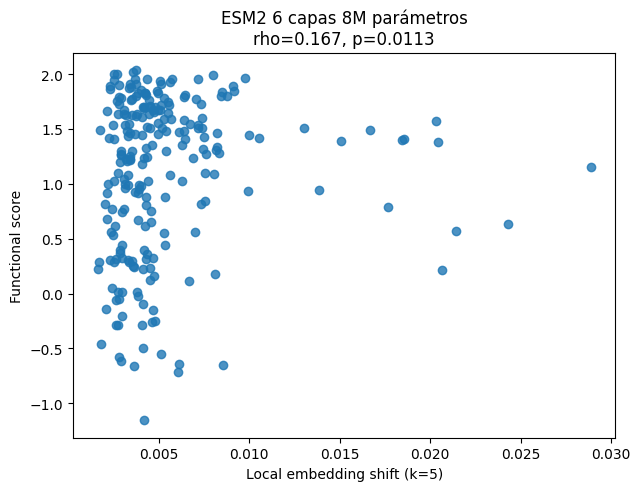

In [ ]:
x = tp53_panel_real["k5_cosine_distance_to_WT"].values
y = tp53_panel_real["functional_score"].values

rho, pval = spearmanr(x, y)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("Local embedding shift (k=5)")
plt.ylabel("Functional score")
plt.title(f"ESM2 6 capas 8M parámetros\nrho={rho:.3f}, p={pval:.3g}")
plt.savefig("corelation-8M.svg")
plt.show()

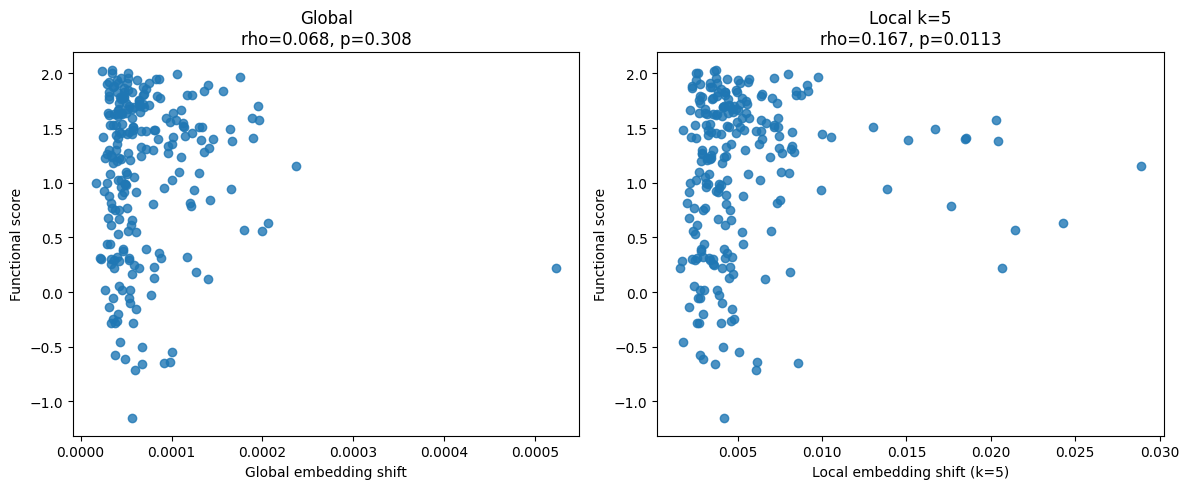

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = tp53_panel_real["global_cosine_distance_to_WT"].values
y = tp53_panel_real["functional_score"].values
rho, pval = spearmanr(x, y)
axes[0].scatter(x, y, alpha=0.8)
axes[0].set_xlabel("Global embedding shift")
axes[0].set_ylabel("Functional score")
axes[0].set_title(f"Global\nrho={rho:.3f}, p={pval:.3g}")

x = tp53_panel_real["k5_cosine_distance_to_WT"].values
y = tp53_panel_real["functional_score"].values
rho, pval = spearmanr(x, y)
axes[1].scatter(x, y, alpha=0.8)
axes[1].set_xlabel("Local embedding shift (k=5)")
axes[1].set_ylabel("Functional score")
axes[1].set_title(f"Local k=5\nrho={rho:.3f}, p={pval:.3g}")

plt.tight_layout()
plt.savefig("embedding-vs-functional-score-global-k5.svg")
plt.show()

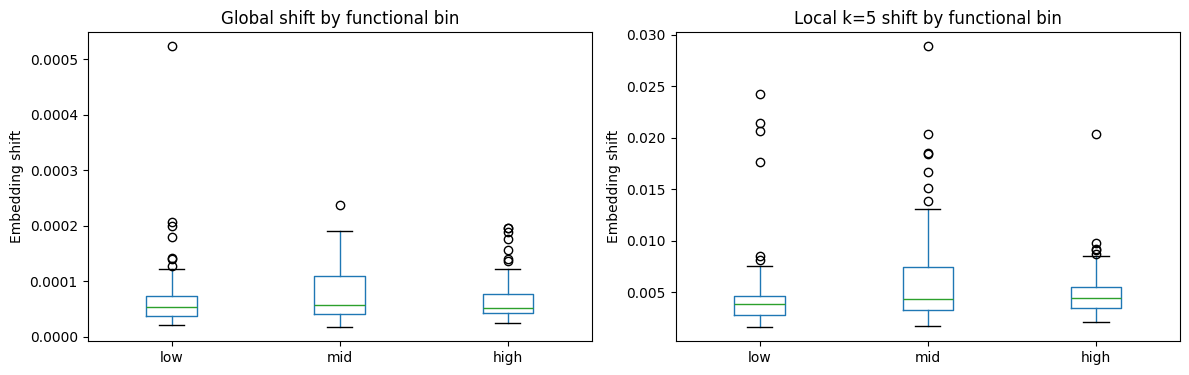

In [ ]:
# tertiles
tp53_panel_real = tp53_panel_real.copy()
tp53_panel_real["functional_bin"] = pd.qcut(
    tp53_panel_real["functional_score"],
    q=3,
    labels=["low", "mid", "high"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tp53_panel_real.boxplot(column="global_cosine_distance_to_WT", by="functional_bin", grid=False, ax=axes[0])
axes[0].set_title("Global shift by functional bin")
axes[0].set_xlabel("")
axes[0].set_ylabel("Embedding shift")

tp53_panel_real.boxplot(column="k5_cosine_distance_to_WT", by="functional_bin", grid=False, ax=axes[1])
axes[1].set_title("Local k=5 shift by functional bin")
axes[1].set_xlabel("")
axes[1].set_ylabel("Embedding shift")

plt.suptitle("")
plt.tight_layout()
plt.savefig("histogram-embeding-shift.svg")
plt.show()


In [ ]:
low = tp53_panel_real.loc[tp53_panel_real["functional_bin"] == "low", "k5_cosine_distance_to_WT"].values
high = tp53_panel_real.loc[tp53_panel_real["functional_bin"] == "high", "k5_cosine_distance_to_WT"].values

u, p = mannwhitneyu(low, high, alternative="two-sided")

print("Mann–Whitney low vs high on k5")
print("n_low =", len(low))
print("n_high =", len(high))
print("U =", u)
print("p =", p)
print("median_low =", np.median(low))
print("median_high =", np.median(high))

Mann–Whitney low vs high on k5
n_low = 76
n_high = 76
U = 2210.0
p = 0.012540728328558246
median_low = 0.003835707902908325
median_high = 0.004395186901092529


In [ ]:
tp53_panel_real["abs_k5"] = tp53_panel_real["k5_cosine_distance_to_WT"].abs()
tp53_panel_real["abs_score"] = tp53_panel_real["functional_score"].abs()

display(
    tp53_panel_real.sort_values("k5_cosine_distance_to_WT", ascending=False)[
        ["mutant", "position", "group", "k5_cosine_distance_to_WT", "functional_score"]
    ].head(20)
)

display(
    tp53_panel_real.sort_values("functional_score", ascending=True)[
        ["mutant", "position", "group", "k5_cosine_distance_to_WT", "functional_score"]
    ].head(20)
)

,mutant,position,group,k5_cosine_distance_to_WT,functional_score
212,V157E,157,comparison_dbd,0.028881,1.149976
211,V157D,157,comparison_dbd,0.024297,0.634803
209,V157A,157,comparison_dbd,0.021405,0.571183
171,A138C,138,comparison_dbd,0.020641,0.216059
222,V157Q,157,comparison_dbd,0.020410,1.382582
217,V157K,157,comparison_dbd,0.020325,1.576725
220,V157N,157,comparison_dbd,0.018527,1.405027
224,V157S,157,comparison_dbd,0.018460,1.396643
214,V157G,157,comparison_dbd,0.017664,0.787983
223,V157R,157,comparison_dbd,0.016686,1.490163


,mutant,position,group,k5_cosine_distance_to_WT,functional_score
143,R282M,282,structural,0.004171,-1.155030
140,R282I,282,structural,0.006061,-0.714421
181,A138N,138,comparison_dbd,0.003641,-0.659453
134,R282C,282,structural,0.008565,-0.650297
210,V157C,157,comparison_dbd,0.006122,-0.642573
15,R175T,175,hotspot,0.002921,-0.614061
133,R282A,282,structural,0.002799,-0.578041
1,R175C,175,hotspot,0.005104,-0.547151
10,R175M,175,hotspot,0.004130,-0.501134
141,R282K,282,structural,0.001789,-0.460369


In [ ]:
corr_table.to_csv("tp53_panel_functional_correlations.csv", index=False)
tp53_panel_real.to_csv("tp53_panel_with_functional_scores.csv", index=False)

print("Saved:")
print("- tp53_panel_functional_correlations.csv")
print("- tp53_panel_with_functional_scores.csv")

Saved:
- tp53_panel_functional_correlations.csv
- tp53_panel_with_functional_scores.csv


In [ ]:
## Correlaciones

from scipy.stats import spearmanr, pearsonr, kendalltau
import pandas as pd
import numpy as np

In [ ]:
def correlation_report(df, x_col, y_col, label=None):
    sub = df[[x_col, y_col]].dropna().copy()

    x = sub[x_col].values
    y = sub[y_col].values

    sp = spearmanr(x, y)
    pr = pearsonr(x, y)
    kt = kendalltau(x, y)

    return {
        "label": label if label is not None else x_col,
        "n": len(sub),
        "spearman_rho": sp.statistic,
        "spearman_p": sp.pvalue,
        "pearson_r": pr.statistic,
        "pearson_p": pr.pvalue,
        "kendall_tau": kt.statistic,
        "kendall_p": kt.pvalue,
    }

In [ ]:
score_col = "score_raw"   # o "combined_lof_dn_score" / "activity_score"

corr_table = pd.DataFrame([
    correlation_report(tp53_panel_real, "global_cosine_distance_to_WT", score_col, "global"),
    correlation_report(tp53_panel_real, "k3_cosine_distance_to_WT", score_col, "local_k3"),
    correlation_report(tp53_panel_real, "k5_cosine_distance_to_WT", score_col, "local_k5"),
])

corr_table

,label,n,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p
0,global,228,0.067765,0.308309,0.028383,0.669886,0.041520,0.350895
1,local_k3,228,0.163292,0.013561,0.088413,0.183425,0.104413,0.018931
2,local_k5,228,0.167434,0.011335,0.085367,0.199046,0.106500,0.016676


In [ ]:
corr_table_round = corr_table.copy()

for col in corr_table_round.columns:
    if col not in ["label", "n"]:
        corr_table_round[col] = corr_table_round[col].round(6)

corr_table_round

,label,n,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p
0,global,228,0.067765,0.308309,0.028383,0.669886,0.041520,0.350895
1,local_k3,228,0.163292,0.013561,0.088413,0.183425,0.104413,0.018931
2,local_k5,228,0.167434,0.011335,0.085367,0.199046,0.106500,0.016676


In [ ]:
## BLOSUM

In [ ]:
from Bio.Align import substitution_matrices
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, kendalltau

blosum62 = substitution_matrices.load("BLOSUM62")


In [ ]:
def get_blosum_score(wt, mut, matrix):
    try:
        return float(matrix[(wt, mut)])
    except Exception:
        try:
            return float(matrix[(mut, wt)])
        except Exception:
            return np.nan

In [ ]:
tp53_panel_real = tp53_panel_real.copy()

tp53_panel_real["blosum62_score"] = [
    get_blosum_score(w, m, blosum62)
    for w, m in zip(tp53_panel_real["wt_aa"], tp53_panel_real["mut_aa"])
]

tp53_panel_real[["mutant", "wt_aa", "mut_aa", "blosum62_score"]].head(20)

,mutant,wt_aa,mut_aa,blosum62_score
0,R175A,R,A,-1.0
1,R175C,R,C,-3.0
2,R175D,R,D,-2.0
3,R175E,R,E,0.0
4,R175F,R,F,-3.0
5,R175G,R,G,-2.0
6,R175H,R,H,0.0
7,R175I,R,I,-3.0
8,R175K,R,K,2.0
9,R175L,R,L,-2.0


In [ ]:
tp53_panel_real["combined_lof_dn_score"] = tp53_panel_real["score_raw"]
tp53_panel_real["activity_score"] = -tp53_panel_real["score_raw"]

tp53_panel_real[["mutant", "combined_lof_dn_score", "activity_score"]].head()

,mutant,combined_lof_dn_score,activity_score
0,R175A,0.747043,-0.747043
1,R175C,-0.547151,0.547151
2,R175D,1.481232,-1.481232
3,R175E,1.711013,-1.711013
4,R175F,1.578232,-1.578232


In [ ]:
def correlation_report(df, x_col, y_col, label=None):
    sub = df[[x_col, y_col]].dropna().copy()

    x = sub[x_col].values
    y = sub[y_col].values

    sp = spearmanr(x, y)
    pr = pearsonr(x, y)
    kt = kendalltau(x, y)

    return {
        "label": label if label is not None else x_col,
        "n": len(sub),
        "spearman_rho": sp.statistic,
        "spearman_p": sp.pvalue,
        "pearson_r": pr.statistic,
        "pearson_p": pr.pvalue,
        "kendall_tau": kt.statistic,
        "kendall_p": kt.pvalue,
    }

In [ ]:
corr_compare_deleterious = pd.DataFrame([
    correlation_report(tp53_panel_real, "blosum62_score", "combined_lof_dn_score", "BLOSUM62 vs deleteriousness"),
    correlation_report(tp53_panel_real, "k5_cosine_distance_to_WT", "combined_lof_dn_score", "ESM local k=5 vs deleteriousness"),
])

corr_compare_deleterious

,label,n,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p
0,BLOSUM62 vs deleteriousness,228,-0.298836,0.000004,-0.286127,0.000011,-0.222308,0.000005
1,ESM local k=5 vs deleteriousness,228,0.167434,0.011335,0.085367,0.199046,0.106500,0.016676


In [ ]:
corr_compare_activity = pd.DataFrame([
    correlation_report(tp53_panel_real, "blosum62_score", "activity_score", "BLOSUM62 vs activity"),
    correlation_report(tp53_panel_real, "k5_cosine_distance_to_WT", "activity_score", "ESM local k=5 vs activity"),
])

corr_compare_activity

,label,n,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p
0,BLOSUM62 vs activity,228,0.298836,0.000004,0.286127,0.000011,0.222308,0.000005
1,ESM local k=5 vs activity,228,-0.167434,0.011335,-0.085367,0.199046,-0.106500,0.016676


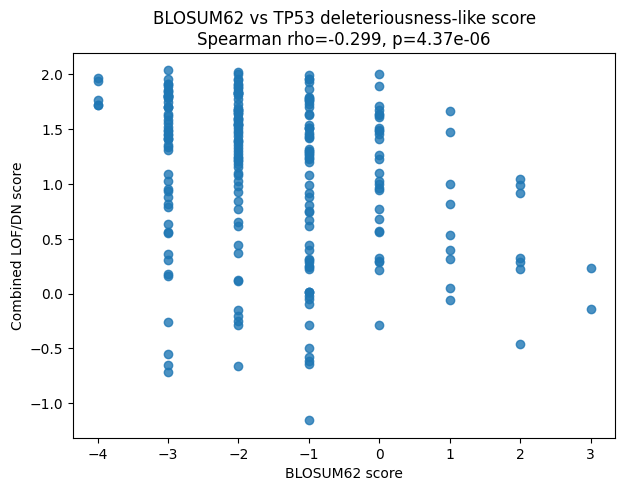

In [ ]:
x = tp53_panel_real["blosum62_score"].values
y = tp53_panel_real["combined_lof_dn_score"].values

rho, pval = spearmanr(x, y)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("BLOSUM62 score")
plt.ylabel("Combined LOF/DN score")
plt.title(f"BLOSUM62 vs TP53 deleteriousness-like score\nSpearman rho={rho:.3f}, p={pval:.3g}")
plt.show()

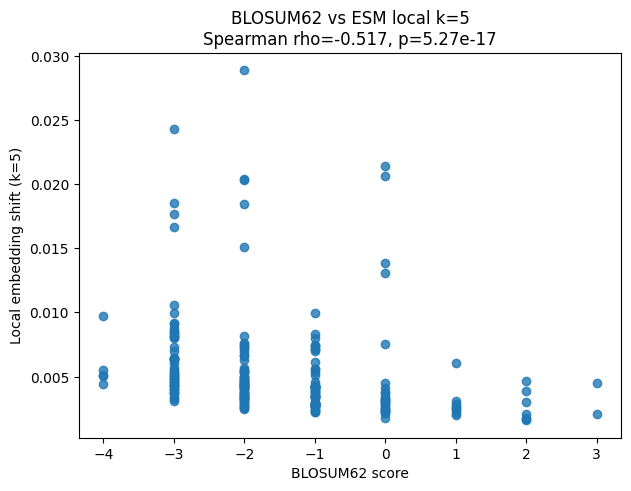

In [ ]:
x = tp53_panel_real["blosum62_score"].values
y = tp53_panel_real["k5_cosine_distance_to_WT"].values

rho, pval = spearmanr(x, y)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("BLOSUM62 score")
plt.ylabel("Local embedding shift (k=5)")
plt.title(f"BLOSUM62 vs ESM local k=5\nSpearman rho={rho:.3f}, p={pval:.3g}")
plt.show()

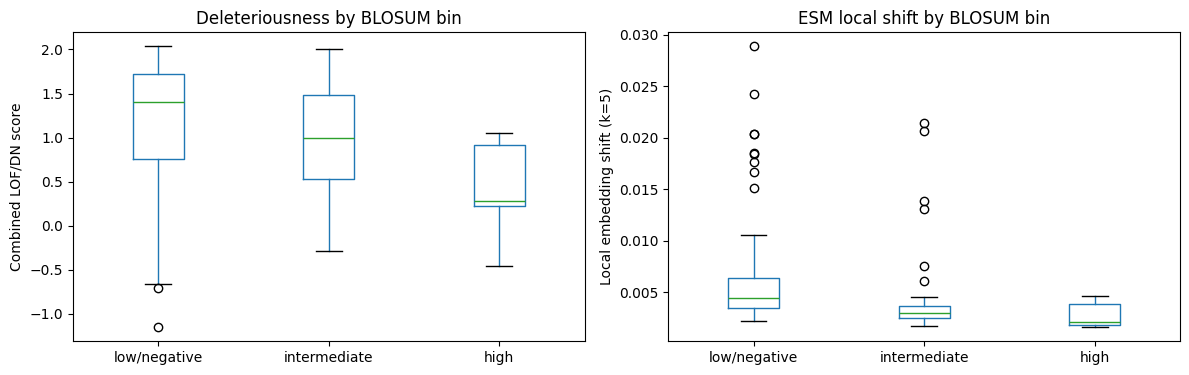

In [ ]:
tp53_panel_real["blosum_bin"] = pd.cut(
    tp53_panel_real["blosum62_score"],
    bins=[-10, -1, 1, 20],
    labels=["low/negative", "intermediate", "high"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tp53_panel_real.boxplot(column="combined_lof_dn_score", by="blosum_bin", grid=False, ax=axes[0])
axes[0].set_title("Deleteriousness by BLOSUM bin")
axes[0].set_xlabel("")
axes[0].set_ylabel("Combined LOF/DN score")

tp53_panel_real.boxplot(column="k5_cosine_distance_to_WT", by="blosum_bin", grid=False, ax=axes[1])
axes[1].set_title("ESM local shift by BLOSUM bin")
axes[1].set_xlabel("")
axes[1].set_ylabel("Local embedding shift (k=5)")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
benchmark_table = pd.DataFrame([
    correlation_report(tp53_panel_real, "blosum62_score", "combined_lof_dn_score", "BLOSUM62"),
    correlation_report(tp53_panel_real, "global_cosine_distance_to_WT", "combined_lof_dn_score", "ESM global"),
    correlation_report(tp53_panel_real, "k5_cosine_distance_to_WT", "combined_lof_dn_score", "ESM local k=5"),
])

benchmark_table

,label,n,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p
0,BLOSUM62,228,-0.298836,0.000004,-0.286127,0.000011,-0.222308,0.000005
1,ESM global,228,0.067765,0.308309,0.028383,0.669886,0.041520,0.350895
2,ESM local k=5,228,0.167434,0.011335,0.085367,0.199046,0.106500,0.016676


In [ ]:
tp53_panel_real.to_csv("tp53_panel_with_blosum.csv", index=False)
benchmark_table.to_csv("tp53_benchmark_blosum_vs_esm.csv", index=False)

print("Saved:")
print("- tp53_panel_with_blosum.csv")
print("- tp53_benchmark_blosum_vs_esm.csv")

Saved:
- tp53_panel_with_blosum.csv
- tp53_benchmark_blosum_vs_esm.csv


In [ ]:
## Comparacion justa


df_cmp = tp53_panel_real.copy()

df_cmp["target"] = df_cmp["combined_lof_dn_score"]
df_cmp["esm_badness"] = df_cmp["k5_cosine_distance_to_WT"]
df_cmp["blosum_badness"] = -df_cmp["blosum62_score"]

df_cmp[[
    "mutant", "target", "esm_badness", "blosum62_score", "blosum_badness"
]].head()

,mutant,target,esm_badness,blosum62_score,blosum_badness
0,R175A,0.747043,0.002931,-1.0,1.0
1,R175C,-0.547151,0.005104,-3.0,3.0
2,R175D,1.481232,0.005405,-2.0,2.0
3,R175E,1.711013,0.004501,0.0,-0.0
4,R175F,1.578232,0.006403,-3.0,3.0


In [ ]:
def subgroup_spearman(df, subset_name, min_n=10):
    sub = df[["target", "esm_badness", "blosum_badness"]].dropna().copy()
    n = len(sub)

    if n < min_n:
        return {
            "subset": subset_name,
            "n": n,
            "rho_esm": np.nan,
            "p_esm": np.nan,
            "rho_blosum": np.nan,
            "p_blosum": np.nan,
            "delta_rho_esm_minus_blosum": np.nan,
        }

    rho_esm, p_esm = spearmanr(sub["esm_badness"], sub["target"])
    rho_blo, p_blo = spearmanr(sub["blosum_badness"], sub["target"])

    return {
        "subset": subset_name,
        "n": n,
        "rho_esm": float(rho_esm),
        "p_esm": float(p_esm),
        "rho_blosum": float(rho_blo),
        "p_blosum": float(p_blo),
        "delta_rho_esm_minus_blosum": float(rho_esm - rho_blo),
    }

In [ ]:
global_cmp = pd.DataFrame([
    subgroup_spearman(df_cmp, "all_mutants", min_n=10)
])

global_cmp

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
0,all_mutants,228,0.167434,0.011335,0.298836,0.000004,-0.131402


In [ ]:
group_results = []

for g, subdf in df_cmp.groupby("group"):
    group_results.append(subgroup_spearman(subdf, f"group={g}", min_n=10))

group_results = pd.DataFrame(group_results).sort_values(
    "delta_rho_esm_minus_blosum", ascending=False
)

group_results

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
0,group=comparison_dbd,76,0.455967,0.000035,0.277236,0.015327,0.178732
2,group=structural,76,0.043363,0.709938,0.250230,0.029249,-0.206867
1,group=hotspot,76,0.148079,0.201750,0.366227,0.001140,-0.218148


In [ ]:
flag_cols = [
    "class_change",
    "hydro_group_change",
    "is_conservative_like",
    "introduces_glycine",
    "introduces_proline",
    "introduces_cysteine",
]

flag_results = []

for col in flag_cols:
    for val in [True, False]:
        subdf = df_cmp[df_cmp[col] == val].copy()
        flag_results.append(subgroup_spearman(subdf, f"{col}={val}", min_n=10))

flag_results = pd.DataFrame(flag_results).sort_values(
    "delta_rho_esm_minus_blosum", ascending=False
)

flag_results

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
1,class_change=False,51,0.462262,0.000638,0.413988,2.528278e-03,0.048274
3,hydro_group_change=False,51,0.462262,0.000638,0.413988,2.528278e-03,0.048274
9,introduces_proline=False,217,0.172078,0.011111,0.290187,1.399925e-05,-0.118109
11,introduces_cysteine=False,217,0.208226,0.002046,0.330398,6.374599e-07,-0.122172
5,is_conservative_like=False,216,0.131023,0.054510,0.254128,1.597525e-04,-0.123105
7,introduces_glycine=False,217,0.166644,0.013977,0.300188,6.771741e-06,-0.133544
6,introduces_glycine=True,11,-0.145455,0.669579,0.021320,9.503887e-01,-0.166775
0,class_change=True,177,0.083562,0.268822,0.288134,1.006485e-04,-0.204572
2,hydro_group_change=True,177,0.083562,0.268822,0.288134,1.006485e-04,-0.204572
4,is_conservative_like=True,12,0.468531,0.124455,0.746474,5.290242e-03,-0.277942


In [ ]:
df_cmp["blosum_bin"] = pd.cut(
    df_cmp["blosum62_score"],
    bins=[-10, -1, 1, 20],
    labels=["low_or_negative", "intermediate", "high"]
)

bin_results = []

for b, subdf in df_cmp.groupby("blosum_bin", observed=False):
    bin_results.append(subgroup_spearman(subdf, f"blosum_bin={b}", min_n=10))

bin_results = pd.DataFrame(bin_results).sort_values(
    "delta_rho_esm_minus_blosum", ascending=False
)

bin_results

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
0,blosum_bin=low_or_negative,182,0.100060,0.178964,0.228461,0.001922,-0.128401
1,blosum_bin=intermediate,37,0.058559,0.730645,0.277297,0.096592,-0.218738
2,blosum_bin=high,9,NaN,NaN,NaN,NaN,NaN


In [ ]:
position_results = []

for pos, subdf in df_cmp.groupby("position"):
    wt = subdf["wt_aa"].iloc[0]
    position_results.append(subgroup_spearman(subdf, f"{wt}{pos}", min_n=8))

position_results = pd.DataFrame(position_results).sort_values(
    "delta_rho_esm_minus_blosum", ascending=False
)

position_results

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
2,P151,19,0.389474,0.099299,-0.204081,0.402004,0.593554
1,A138,19,0.042105,0.864108,-0.184929,0.448490,0.227034
4,R175,19,0.159649,0.513847,0.018873,0.938871,0.140776
11,R282,19,-0.071930,0.769806,-0.168963,0.489259,0.097033
5,C176,19,0.333333,0.163139,0.302764,0.207687,0.030569
8,G245,19,0.007018,0.977254,0.179868,0.461220,-0.172850
9,R248,19,0.221053,0.363110,0.414318,0.077796,-0.193265
3,V157,19,0.024561,0.920498,0.237133,0.328319,-0.212572
10,R249,19,-0.105263,0.668013,0.138406,0.572026,-0.243669
0,T125,19,0.338596,0.156190,0.589693,0.007876,-0.251096


In [ ]:
all_subgroup_results = pd.concat(
    [
        global_cmp.assign(kind="global"),
        group_results.assign(kind="group"),
        flag_results.assign(kind="flag"),
        bin_results.assign(kind="blosum_bin"),
        position_results.assign(kind="position"),
    ],
    ignore_index=True
)

all_subgroup_results.sort_values("delta_rho_esm_minus_blosum", ascending=False).head(30)

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum,kind
19,P151,19,0.389474,0.099299,-0.204081,4.020036e-01,0.593554,position
20,A138,19,0.042105,0.864108,-0.184929,4.484904e-01,0.227034,position
1,group=comparison_dbd,76,0.455967,0.000035,0.277236,1.532701e-02,0.178732,group
21,R175,19,0.159649,0.513847,0.018873,9.388711e-01,0.140776,position
22,R282,19,-0.071930,0.769806,-0.168963,4.892587e-01,0.097033,position
5,hydro_group_change=False,51,0.462262,0.000638,0.413988,2.528278e-03,0.048274,flag
4,class_change=False,51,0.462262,0.000638,0.413988,2.528278e-03,0.048274,flag
23,C176,19,0.333333,0.163139,0.302764,2.076870e-01,0.030569,position
6,introduces_proline=False,217,0.172078,0.011111,0.290187,1.399925e-05,-0.118109,flag
7,introduces_cysteine=False,217,0.208226,0.002046,0.330398,6.374599e-07,-0.122172,flag


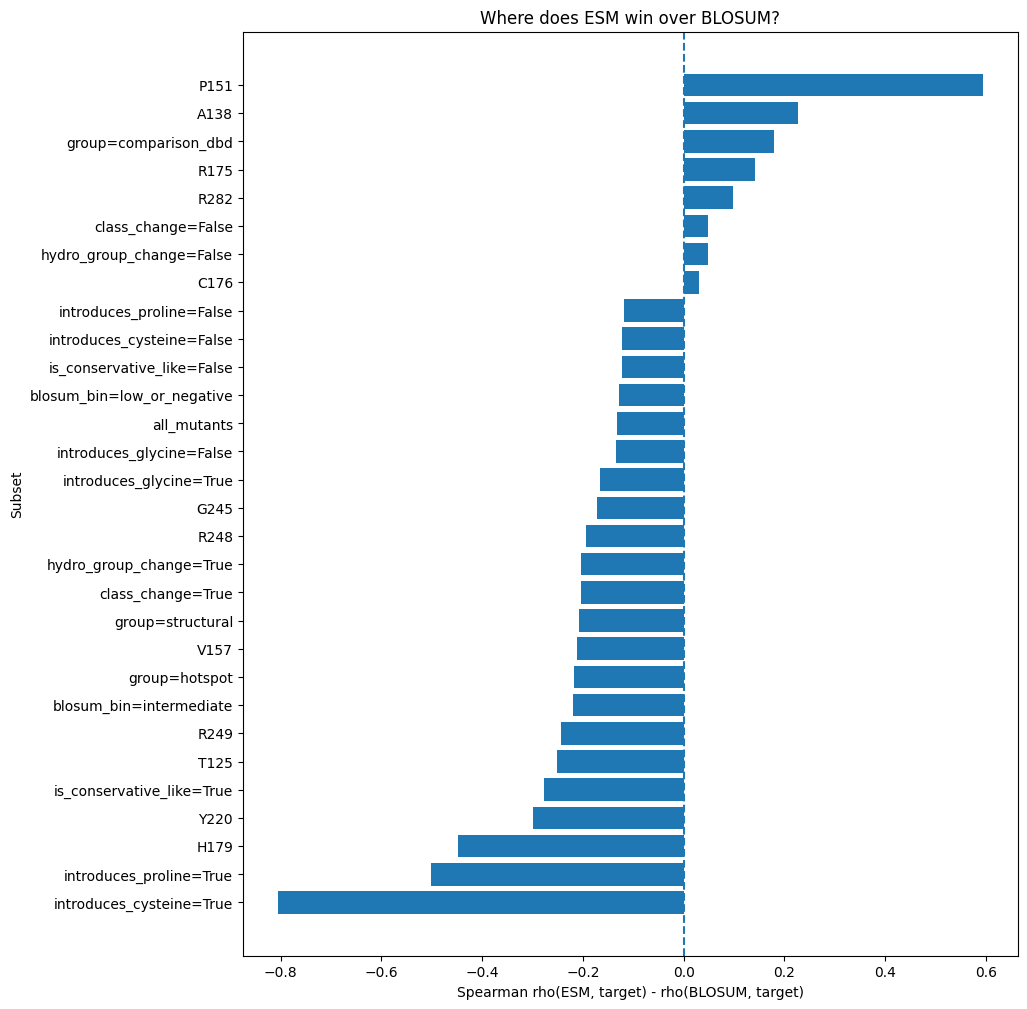

In [ ]:
plot_df = all_subgroup_results.copy()
plot_df = plot_df.dropna(subset=["delta_rho_esm_minus_blosum"])
plot_df = plot_df.sort_values("delta_rho_esm_minus_blosum", ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(plot_df["subset"], plot_df["delta_rho_esm_minus_blosum"])
plt.axvline(0, linestyle="--")
plt.xlabel("Spearman rho(ESM, target) - rho(BLOSUM, target)")
plt.ylabel("Subset")
plt.title("Where does ESM win over BLOSUM?")
plt.show()

In [ ]:
reliable_subsets = all_subgroup_results[
    all_subgroup_results["n"] >= 12
].sort_values("delta_rho_esm_minus_blosum", ascending=False)

reliable_subsets

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum,kind
19,P151,19,0.389474,0.099299,-0.204081,4.020036e-01,0.593554,position
20,A138,19,0.042105,0.864108,-0.184929,4.484904e-01,0.227034,position
1,group=comparison_dbd,76,0.455967,0.000035,0.277236,1.532701e-02,0.178732,group
21,R175,19,0.159649,0.513847,0.018873,9.388711e-01,0.140776,position
22,R282,19,-0.071930,0.769806,-0.168963,4.892587e-01,0.097033,position
5,hydro_group_change=False,51,0.462262,0.000638,0.413988,2.528278e-03,0.048274,flag
4,class_change=False,51,0.462262,0.000638,0.413988,2.528278e-03,0.048274,flag
23,C176,19,0.333333,0.163139,0.302764,2.076870e-01,0.030569,position
6,introduces_proline=False,217,0.172078,0.011111,0.290187,1.399925e-05,-0.118109,flag
7,introduces_cysteine=False,217,0.208226,0.002046,0.330398,6.374599e-07,-0.122172,flag


In [ ]:
def bootstrap_delta_spearman(df, n_boot=2000, random_state=123):
    rng = np.random.default_rng(random_state)

    sub = df[["target", "esm_badness", "blosum_badness"]].dropna().copy()
    n = len(sub)

    if n < 10:
        return {
            "n": n,
            "delta_rho": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        }

    # delta observado
    rho_esm, _ = spearmanr(sub["esm_badness"], sub["target"])
    rho_blo, _ = spearmanr(sub["blosum_badness"], sub["target"])
    delta_obs = rho_esm - rho_blo

    boot = []
    idx = np.arange(n)

    for _ in range(n_boot):
        samp = rng.choice(idx, size=n, replace=True)
        s = sub.iloc[samp]
        r1, _ = spearmanr(s["esm_badness"], s["target"])
        r2, _ = spearmanr(s["blosum_badness"], s["target"])
        boot.append(r1 - r2)

    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

    return {
        "n": n,
        "delta_rho": float(delta_obs),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
    }

In [ ]:
bootstrap_rows = []

# global
res = bootstrap_delta_spearman(df_cmp, n_boot=2000)
bootstrap_rows.append({"subset": "all_mutants", **res})

# grupos
for g, subdf in df_cmp.groupby("group"):
    res = bootstrap_delta_spearman(subdf, n_boot=2000)
    bootstrap_rows.append({"subset": f"group={g}", **res})

# flags
for col in [
    "class_change",
    "is_conservative_like",
    "introduces_glycine",
    "introduces_proline",
    "introduces_cysteine",
]:
    for val in [True, False]:
        subdf = df_cmp[df_cmp[col] == val]
        res = bootstrap_delta_spearman(subdf, n_boot=2000)
        bootstrap_rows.append({"subset": f"{col}={val}", **res})

bootstrap_df = pd.DataFrame(bootstrap_rows).sort_values("delta_rho", ascending=False)
bootstrap_df

/tmp/ipykernel_931/1986419304.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])
/tmp/ipykernel_931/1986419304.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])
/tmp/ipykernel_931/1986419304.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])


,subset,n,delta_rho,ci_low,ci_high
1,group=comparison_dbd,76,0.178732,-0.061566,0.409112
5,class_change=False,51,0.048274,-0.277076,0.342306
11,introduces_proline=False,217,-0.118109,-0.238440,0.010226
13,introduces_cysteine=False,217,-0.122172,-0.237242,-0.004698
7,is_conservative_like=False,216,-0.123105,-0.254097,0.010321
0,all_mutants,228,-0.131402,-0.255693,-0.008009
9,introduces_glycine=False,217,-0.133544,-0.256213,-0.013604
8,introduces_glycine=True,11,-0.166775,NaN,NaN
4,class_change=True,177,-0.204572,-0.339957,-0.066839
3,group=structural,76,-0.206867,-0.389552,-0.020499


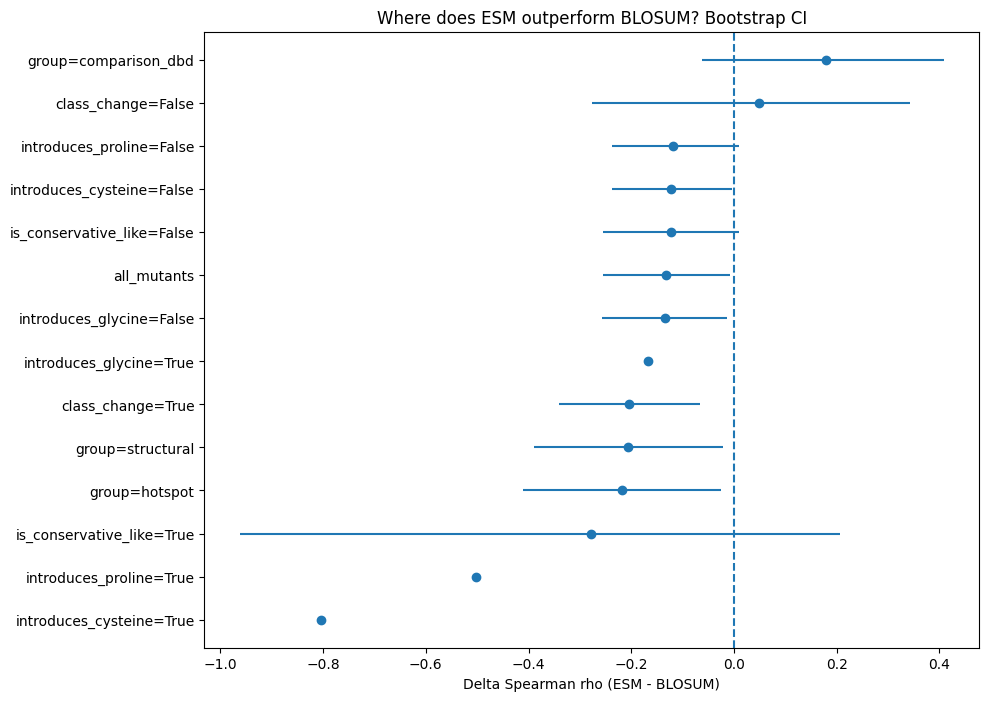

In [ ]:
tmp = bootstrap_df.dropna(subset=["delta_rho"]).sort_values("delta_rho", ascending=True)

plt.figure(figsize=(10, 8))
y = np.arange(len(tmp))

plt.errorbar(
    x=tmp["delta_rho"],
    y=y,
    xerr=[
        tmp["delta_rho"] - tmp["ci_low"],
        tmp["ci_high"] - tmp["delta_rho"]
    ],
    fmt="o"
)

plt.yticks(y, tmp["subset"])
plt.axvline(0, linestyle="--")
plt.xlabel("Delta Spearman rho (ESM - BLOSUM)")
plt.title("Where does ESM outperform BLOSUM? Bootstrap CI")
plt.show()

In [ ]:
all_subgroup_results.to_csv("tp53_esm_vs_blosum_subgroup_correlations.csv", index=False)
bootstrap_df.to_csv("tp53_esm_vs_blosum_bootstrap_delta_rho.csv", index=False)

print("Saved:")
print("- tp53_esm_vs_blosum_subgroup_correlations.csv")
print("- tp53_esm_vs_blosum_bootstrap_delta_rho.csv")

Saved:
- tp53_esm_vs_blosum_subgroup_correlations.csv
- tp53_esm_vs_blosum_bootstrap_delta_rho.csv


In [ ]:
### Figura final

In [ ]:

final_subsets = [
    "all_mutants",
    "group=comparison_dbd",
    "group=hotspot",
]

final_df = bootstrap_df[bootstrap_df["subset"].isin(final_subsets)].copy()

order_map = {
    "all_mutants": 0,
    "group=comparison_dbd": 1,
    "group=hotspot": 2,
}

label_map = {
    "all_mutants": "All mutants",
    "group=comparison_dbd": "Comparison DBD",
    "group=hotspot": "Hotspots",
}

final_df["order"] = final_df["subset"].map(order_map)
final_df["label"] = final_df["subset"].map(label_map)
final_df = final_df.sort_values("order").reset_index(drop=True)

final_df

,subset,n,delta_rho,ci_low,ci_high,order,label
0,all_mutants,228,-0.131402,-0.255693,-0.008009,0,All mutants
1,group=comparison_dbd,76,0.178732,-0.061566,0.409112,1,Comparison DBD
2,group=hotspot,76,-0.218148,-0.410314,-0.025644,2,Hotspots


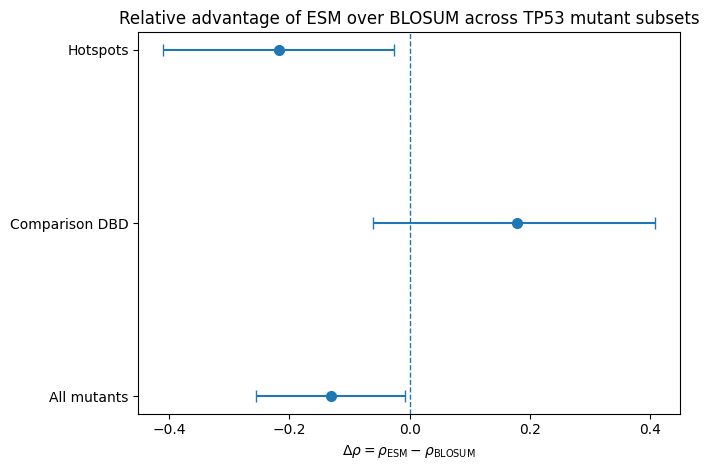

In [ ]:
plt.figure(figsize=(7, 4.8))

y = np.arange(len(final_df))

x = final_df["delta_rho"].values
xerr_left = x - final_df["ci_low"].values
xerr_right = final_df["ci_high"].values - x

plt.errorbar(
    x=x,
    y=y,
    xerr=[xerr_left, xerr_right],
    fmt="o",
    capsize=4,
    markersize=7,
    linewidth=1.5,
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y, final_df["label"])
plt.xlabel(r"$\Delta \rho = \rho_{\mathrm{ESM}} - \rho_{\mathrm{BLOSUM}}$")
plt.title("Relative advantage of ESM over BLOSUM across TP53 mutant subsets")

plt.tight_layout()
plt.show()

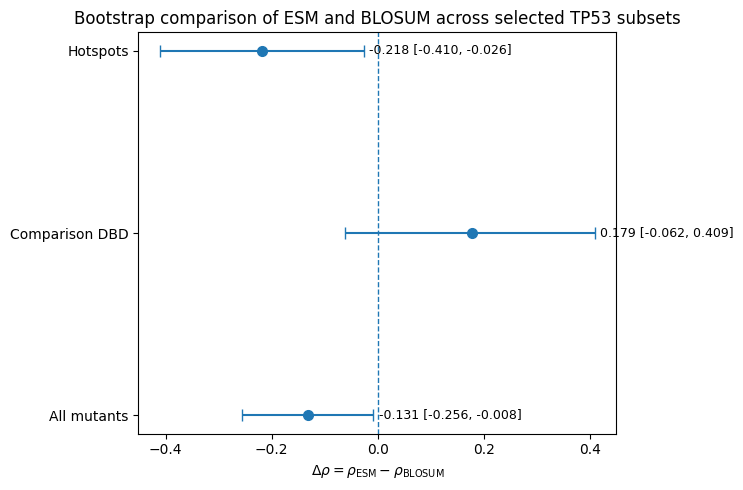

In [ ]:
plt.figure(figsize=(7.5, 5))

y = np.arange(len(final_df))
x = final_df["delta_rho"].values
xerr_left = x - final_df["ci_low"].values
xerr_right = final_df["ci_high"].values - x

plt.errorbar(
    x=x,
    y=y,
    xerr=[xerr_left, xerr_right],
    fmt="o",
    capsize=4,
    markersize=7,
    linewidth=1.5,
)

plt.axvline(0, linestyle="--", linewidth=1)

for i, row in final_df.iterrows():
    txt = f"{row['delta_rho']:.3f} [{row['ci_low']:.3f}, {row['ci_high']:.3f}]"
    plt.text(row["ci_high"] + 0.01, i, txt, va="center", fontsize=9)

plt.yticks(y, final_df["label"])
plt.xlabel(r"$\Delta \rho = \rho_{\mathrm{ESM}} - \rho_{\mathrm{BLOSUM}}$")
plt.title("Bootstrap comparison of ESM and BLOSUM across selected TP53 subsets")

plt.tight_layout()
plt.show()

In [ ]:
final_table = final_df[["label", "n", "delta_rho", "ci_low", "ci_high"]].copy()

for col in ["delta_rho", "ci_low", "ci_high"]:
    final_table[col] = final_table[col].round(3)

final_table

,label,n,delta_rho,ci_low,ci_high
0,All mutants,228,-0.131,-0.256,-0.008
1,Comparison DBD,76,0.179,-0.062,0.409
2,Hotspots,76,-0.218,-0.410,-0.026


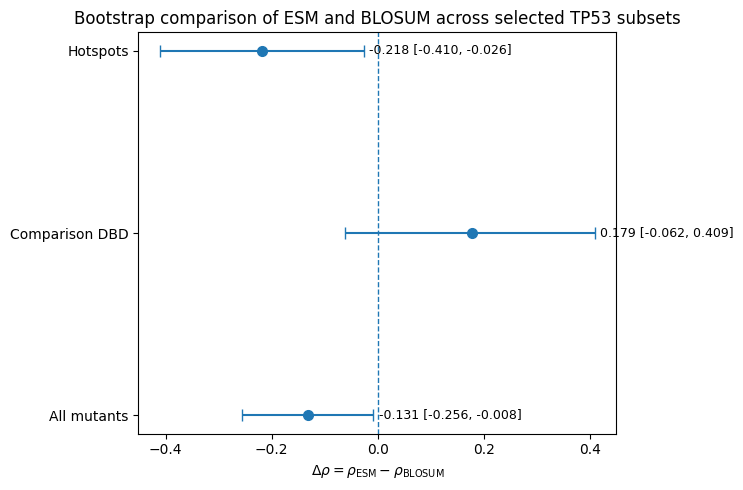

Saved: tp53_esm_vs_blosum_selected_subsets.png


In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5))

y = np.arange(len(final_df))
x = final_df["delta_rho"].values
xerr_left = x - final_df["ci_low"].values
xerr_right = final_df["ci_high"].values - x

ax.errorbar(
    x=x,
    y=y,
    xerr=[xerr_left, xerr_right],
    fmt="o",
    capsize=4,
    markersize=7,
    linewidth=1.5,
)

ax.axvline(0, linestyle="--", linewidth=1)

for i, row in final_df.iterrows():
    txt = f"{row['delta_rho']:.3f} [{row['ci_low']:.3f}, {row['ci_high']:.3f}]"
    ax.text(row["ci_high"] + 0.01, i, txt, va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(final_df["label"])
ax.set_xlabel(r"$\Delta \rho = \rho_{\mathrm{ESM}} - \rho_{\mathrm{BLOSUM}}$")
ax.set_title("Bootstrap comparison of ESM and BLOSUM across selected TP53 subsets")

plt.tight_layout()
plt.savefig("tp53_esm_vs_blosum_selected_subsets.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: tp53_esm_vs_blosum_selected_subsets.png")